### Required Assignment 5.1: Will the Customer Accept the Coupon?

**Context**

Imagine driving through town and a coupon is delivered to your cell phone for a restaurant near where you are driving. Would you accept that coupon and take a short detour to the restaurant? Would you accept the coupon but use it on a subsequent trip? Would you ignore the coupon entirely? What if the coupon was for a bar instead of a restaurant? What about a coffee house? Would you accept a bar coupon with a minor passenger in the car? What about if it was just you and your partner in the car? Would weather impact the rate of acceptance? What about the time of day?

Obviously, proximity to the business is a factor on whether the coupon is delivered to the driver or not, but what are the factors that determine whether a driver accepts the coupon once it is delivered to them? How would you determine whether a driver is likely to accept a coupon?

**Overview**

The goal of this project is to use what you know about visualizations and probability distributions to distinguish between customers who accepted a driving coupon versus those that did not.

**Data**

This data comes to us from the UCI Machine Learning repository and was collected via a survey on Amazon Mechanical Turk. The survey describes different driving scenarios including the destination, current time, weather, passenger, etc., and then ask the person whether he will accept the coupon if he is the driver. Answers that the user will drive there ‘right away’ or ‘later before the coupon expires’ are labeled as ‘Y = 1’ and answers ‘no, I do not want the coupon’ are labeled as ‘Y = 0’.  There are five different types of coupons -- less expensive restaurants (under \$20), coffee houses, carry out & take away, bar, and more expensive restaurants (\$20 - $50).

**Deliverables**

Your final product should be a brief report that highlights the differences between customers who did and did not accept the coupons.  To explore the data you will utilize your knowledge of plotting, statistical summaries, and visualization using Python. You will publish your findings in a public facing github repository as your first portfolio piece.





### Data Description
Keep in mind that these values mentioned below are average values.

The attributes of this data set include:
1. User attributes
    -  Gender: male, female
    -  Age: below 21, 21 to 25, 26 to 30, etc.
    -  Marital Status: single, married partner, unmarried partner, or widowed
    -  Number of children: 0, 1, or more than 1
    -  Education: high school, bachelors degree, associates degree, or graduate degree
    -  Occupation: architecture & engineering, business & financial, etc.
    -  Annual income: less than \\$12500, \\$12500 - \\$24999, \\$25000 - \\$37499, etc.
    -  Number of times that he/she goes to a bar: 0, less than 1, 1 to 3, 4 to 8 or greater than 8
    -  Number of times that he/she buys takeaway food: 0, less than 1, 1 to 3, 4 to 8 or greater
    than 8
    -  Number of times that he/she goes to a coffee house: 0, less than 1, 1 to 3, 4 to 8 or
    greater than 8
    -  Number of times that he/she eats at a restaurant with average expense less than \\$20 per
    person: 0, less than 1, 1 to 3, 4 to 8 or greater than 8
    -  Number of times that he/she goes to a bar: 0, less than 1, 1 to 3, 4 to 8 or greater than 8
    

2. Contextual attributes
    - Driving destination: home, work, or no urgent destination
    - Location of user, coupon and destination: we provide a map to show the geographical
    location of the user, destination, and the venue, and we mark the distance between each
    two places with time of driving. The user can see whether the venue is in the same
    direction as the destination.
    - Weather: sunny, rainy, or snowy
    - Temperature: 30F, 55F, or 80F
    - Time: 10AM, 2PM, or 6PM
    - Passenger: alone, partner, kid(s), or friend(s)


3. Coupon attributes
    - time before it expires: 2 hours or one day

In [66]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import numpy as np

### Problems

Use the prompts below to get started with your data analysis.  

1. Read in the `coupons.csv` file.




In [67]:
data = pd.read_csv('data/coupons.csv')

In [68]:
data.head()

,destination,passanger,weather,temperature,time,coupon,expiration,gender,age,maritalStatus,...,CoffeeHouse,CarryAway,RestaurantLessThan20,Restaurant20To50,toCoupon_GEQ5min,toCoupon_GEQ15min,toCoupon_GEQ25min,direction_same,direction_opp,Y
0,No Urgent Place,Alone,Sunny,55,2PM,Restaurant(<20),1d,Female,21,Unmarried partner,...,never,NaN,4~8,1~3,1,0,0,0,1,1
1,No Urgent Place,Friend(s),Sunny,80,10AM,Coffee House,2h,Female,21,Unmarried partner,...,never,NaN,4~8,1~3,1,0,0,0,1,0
2,No Urgent Place,Friend(s),Sunny,80,10AM,Carry out & Take away,2h,Female,21,Unmarried partner,...,never,NaN,4~8,1~3,1,1,0,0,1,1
3,No Urgent Place,Friend(s),Sunny,80,2PM,Coffee House,2h,Female,21,Unmarried partner,...,never,NaN,4~8,1~3,1,1,0,0,1,0
4,No Urgent Place,Friend(s),Sunny,80,2PM,Coffee House,1d,Female,21,Unmarried partner,...,never,NaN,4~8,1~3,1,1,0,0,1,0


2. Investigate the dataset for missing or problematic data.

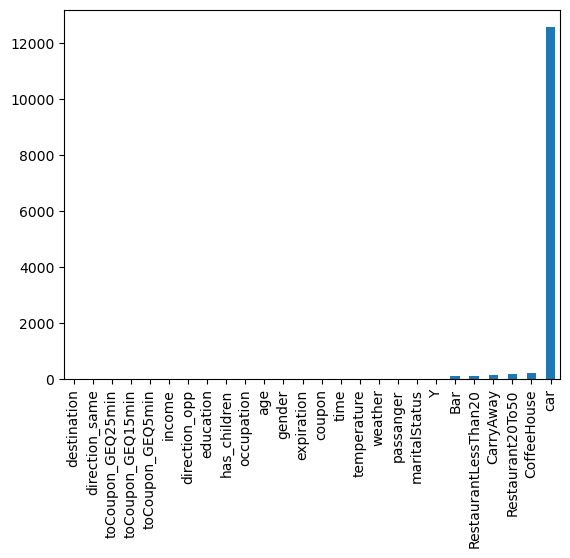

In [69]:
# i create a plot of missing data
data.isnull().sum().sort_values().plot(kind = 'bar')
plt.savefig('images/missing_data.png')
plt.show()


3. Decide what to do about your missing data -- drop, replace, other...

In [70]:
# for field "car" there are too many null values, so we can't drop all the records with null values.
# I will fill the null values with "NA" for column "car"
# for others fields there are not too many missing values, so we could just drop the records with null values

data['car'] = data['car'].fillna('NA')
data = data.dropna()
data.head()

,destination,passanger,weather,temperature,time,coupon,expiration,gender,age,maritalStatus,...,CoffeeHouse,CarryAway,RestaurantLessThan20,Restaurant20To50,toCoupon_GEQ5min,toCoupon_GEQ15min,toCoupon_GEQ25min,direction_same,direction_opp,Y
22,No Urgent Place,Alone,Sunny,55,2PM,Restaurant(<20),1d,Male,21,Single,...,less1,4~8,4~8,less1,1,0,0,0,1,1
23,No Urgent Place,Friend(s),Sunny,80,10AM,Coffee House,2h,Male,21,Single,...,less1,4~8,4~8,less1,1,0,0,0,1,0
24,No Urgent Place,Friend(s),Sunny,80,10AM,Bar,1d,Male,21,Single,...,less1,4~8,4~8,less1,1,0,0,0,1,1
25,No Urgent Place,Friend(s),Sunny,80,10AM,Carry out & Take away,2h,Male,21,Single,...,less1,4~8,4~8,less1,1,1,0,0,1,0
26,No Urgent Place,Friend(s),Sunny,80,2PM,Coffee House,1d,Male,21,Single,...,less1,4~8,4~8,less1,1,0,0,0,1,0


4. What proportion of the total observations chose to accept the coupon?



In [71]:
data['Y'].value_counts(normalize = True)
#The proportion of the total observations who chose to accept the coupon is about 57%

Y
1    0.569335
0    0.430665
Name: proportion, dtype: float64

5. Use a bar plot to visualize the `coupon` column.

<Axes: ylabel='coupon'>

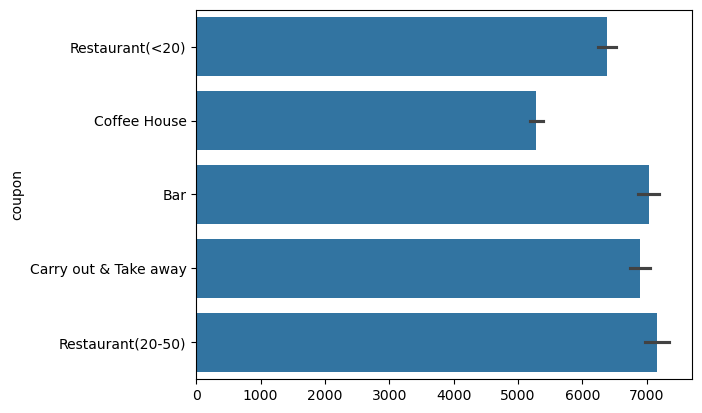

In [72]:
sns.barplot(data["coupon"])

6. Use a histogram to visualize the temperature column.

Text(0.5, 1.0, 'Histogram of Temperature')

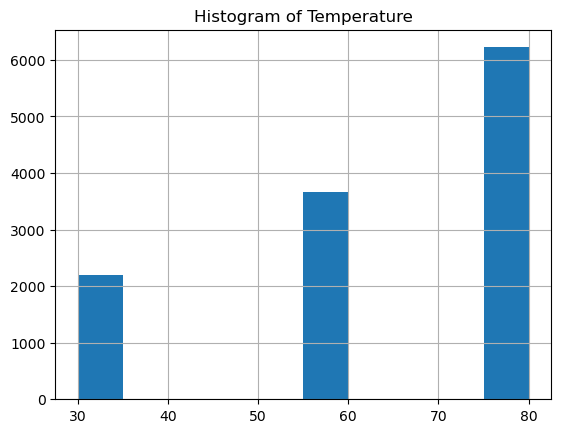

In [73]:
data.hist("temperature")
plt.title("Histogram of Temperature")

**Investigating the Bar Coupons**

Now, we will lead you through an exploration of just the bar related coupons.  

1. Create a new `DataFrame` that contains just the bar coupons.


In [74]:
data_coupons = data.query('coupon == "Bar"')
data_coupons.head()

,destination,passanger,weather,temperature,time,coupon,expiration,gender,age,maritalStatus,...,CoffeeHouse,CarryAway,RestaurantLessThan20,Restaurant20To50,toCoupon_GEQ5min,toCoupon_GEQ15min,toCoupon_GEQ25min,direction_same,direction_opp,Y
24,No Urgent Place,Friend(s),Sunny,80,10AM,Bar,1d,Male,21,Single,...,less1,4~8,4~8,less1,1,0,0,0,1,1
35,Home,Alone,Sunny,55,6PM,Bar,1d,Male,21,Single,...,less1,4~8,4~8,less1,1,0,0,1,0,1
39,Work,Alone,Sunny,55,7AM,Bar,1d,Male,21,Single,...,less1,4~8,4~8,less1,1,1,1,0,1,1
46,No Urgent Place,Friend(s),Sunny,80,10AM,Bar,1d,Male,46,Single,...,4~8,1~3,1~3,never,1,0,0,0,1,0
57,Home,Alone,Sunny,55,6PM,Bar,1d,Male,46,Single,...,4~8,1~3,1~3,never,1,0,0,1,0,0


2. What proportion of bar coupons were accepted?


In [75]:
data_coupons['Y'].value_counts(normalize = True)
#The proportion of bar coupons which were accepted is about 41%

Y
0    0.588082
1    0.411918
Name: proportion, dtype: float64

3. Compare the acceptance rate between those who went to a bar 3 or fewer times a month to those who went more.


In [76]:
# we check the list of possible answered values for Bar
data_coupons.groupby('Bar').size()
# we see that the list of possible values is 1~3, 4~8, gt8, less1, and never
# we compare the acceptance rate between those who went to a bar 3 or fewer times a month (Bar value should be in the list ['1~3','less1', 'never']) to those who went more
data_coupons.groupby(data_coupons['Bar'].isin(['1~3','less1', 'never']))['Y'].value_counts(normalize = True)
# we see that the acceptance rate of those who went to a bar 3 or fewer times a month is about 37%
# and the acceptance rate of those who went more is about 76%
# so the acceptance rate of those who went to a bar 3 or fewer times a month is much lower than those who went more

Bar    Y
False  1    0.761658
       0    0.238342
True   0    0.627326
       1    0.372674
Name: proportion, dtype: float64

4. Compare the acceptance rate between drivers who go to a bar more than once a month and are over the age of 25 to the all others.  Is there a difference?


In [77]:
# we check the list of possible answered values for Bar
data_coupons.groupby('Bar').size()
# we see that the list of possible values is 1~3, 4~8, gt8, less1, and never
# so to filter for drivers who go to a bar more than once a month we create the below list : list_more_than_once_a_month
list_more_than_once_a_month = ['1~3', '4~8', 'gt8']

# we check the list of possible answered values for Age
data_coupons.groupby('age').size()
# we see that the list of possible values is 21, 26, 31, 36, 41, 46, 50plus, below21
# so to filter for drivers who are over 25 years old we create the below list : list_more_than_25
list_more_than_25 = ['26', '31', '36', '41', '46', '50plus']

# We compare the acceptance rate between drivers who go to a bar more than once a month and are over the age of 25 to the all others.
data_coupons.groupby((data_coupons['age'].isin(list_more_than_25)) & (data_coupons['Bar'].isin(list_more_than_once_a_month)))['Y'].value_counts(normalize = True)

# We see that the acceptance rate of drivers who go to a bar more than once a month and are over the age of 25 is about 69% and the acceptance rate of all others is about 34%.
# So the coupon is a lot more accepted by the drivers who go to a bar more than once a month and are over the age of 25 than by all the others

       Y
False  0    0.662252
       1    0.337748
True   1    0.689826
       0    0.310174
Name: proportion, dtype: float64

5. Use the same process to compare the acceptance rate between drivers who go to bars more than once a month and had passengers that were not a kid and had occupations other than farming, fishing, or forestry.


In [78]:
# we check the list of possible answered values for passanger
data_coupons.groupby('passanger').size()
# we see that the list of possible values is Alone, Friend(s), Kid(s), Partner
# so to filter for drivers who had passengers that were not a kid we need to use condition data_coupons['passanger'] != 'Kid(s)'

# we check the list of possible answered values for occupation
data_coupons.groupby('occupation').size()
# to filter for drivers who had occupations other than farming, fishing, or forestry we need to use condition data_coupons['occupation'] != 'Farming Fishing & Forestry'
# We compare the acceptance rate between drivers who go to bars more than once a month and had passengers that were not a kid and had occupations other than farming, fishing, or forestry to the all others.

data_coupons.groupby((data_coupons['Bar'].isin(list_more_than_once_a_month))&(data_coupons['passanger'] != 'Kid(s)')&(data_coupons['occupation'] != 'Farming Fishing & Forestry'))['Y'].value_counts(normalize = True)

# We see that the acceptance rate of drivers who go to bars more than once a month and had passengers that were not a kid and had occupations other than farming, fishing, or forestry is about 71% and the acceptance rate of all the others is about 30%
# So the coupon is a lot more accepted by the drivers who go to bars more than once a month and had passengers that were not a kid and had occupations other than farming, fishing, or forestry than the others

       Y
False  0    0.702097
       1    0.297903
True   1    0.709434
       0    0.290566
Name: proportion, dtype: float64

6. Compare the acceptance rates between those drivers who:

- go to bars more than once a month, had passengers that were not a kid, and were not widowed *OR*
- go to bars more than once a month and are under the age of 30 *OR*
- go to cheap restaurants more than 4 times a month and income is less than 50K.



In [79]:
# we calculate the acceptance rate of drivers who go to bars more than once a month, had passengers that were not a kid, and were not widowed
data_coupons.query('Bar in @list_more_than_once_a_month and passanger != "Kid(s)" and maritalStatus != "Widowed"')['Y'].value_counts(normalize = True)
# the acceptance rate is about 71%

# we calculate the acceptance rate of drivers who go to bars more than once a month and are under the age of 30
list_less_than_30 = ['21', '26', 'below21']
data_coupons.query('Bar in @list_more_than_once_a_month and age in @list_less_than_30')['Y'].value_counts(normalize = True)
# the acceptance rate is about 72%

# we calculate the acceptance rate of drivers who go to cheap restaurants more than 4 times a month and income is less than 50K
list_more_than_4_times_a_month = ['4~8', 'gt8']
list_income_less_than_50K = ['$12500 - $24999', 'Less than $12500']
data_coupons.query('RestaurantLessThan20 in @list_more_than_4_times_a_month and income in @list_income_less_than_50K')['Y'].value_counts(normalize = True)
# the acceptance rate is about 43%

Y
0    0.568047
1    0.431953
Name: proportion, dtype: float64

7.  Based on these observations, what do you hypothesize about drivers who accepted the bar coupons?

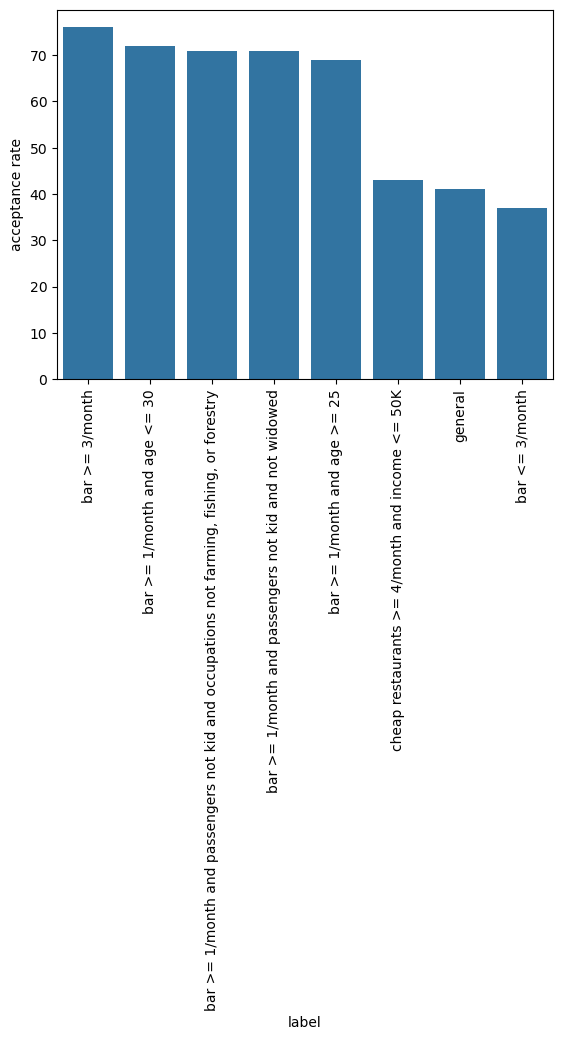

In [80]:
df = pd.DataFrame({'label': ['general', 'bar <= 3/month', 'bar >= 3/month', 'bar >= 1/month and age >= 25', 'bar >= 1/month and passengers not kid and occupations not farming, fishing, or forestry', 'bar >= 1/month and passengers not kid and not widowed', 'bar >= 1/month and age <= 30', 'cheap restaurants >= 4/month and income <= 50K'], 'acceptance rate': [41, 37, 76, 69, 71 , 71, 72, 43]}).sort_values('acceptance rate', ascending = False)             
# I create a barplot to help vizualise better the previous observations and sort the results by descending order of acceptance rate
sns.barplot(
            x='label', 
            y='acceptance rate', 
              data=df
            ).tick_params(axis='x', labelrotation=90)
# Based on the results, we could say that :
# 1) the more frequent the drivers go to a bar each month, the more likely they are to accept the coupons
# 2) drivers with a lower income and who go often to cheap restaurasnts are less likely to accept the coupons

### Independent Investigation

Using the bar coupon example as motivation, you are to explore one of the other coupon groups and try to determine the characteristics of passengers who accept the coupons.  

In [98]:
# import plotly.express to draw some plots
import plotly.express as px
# In the data dataframe, I replace the sign $ by nothing because it will cause issues with the histograms I will try to plot below
data['income'] = data['income'].str.replace("$","")

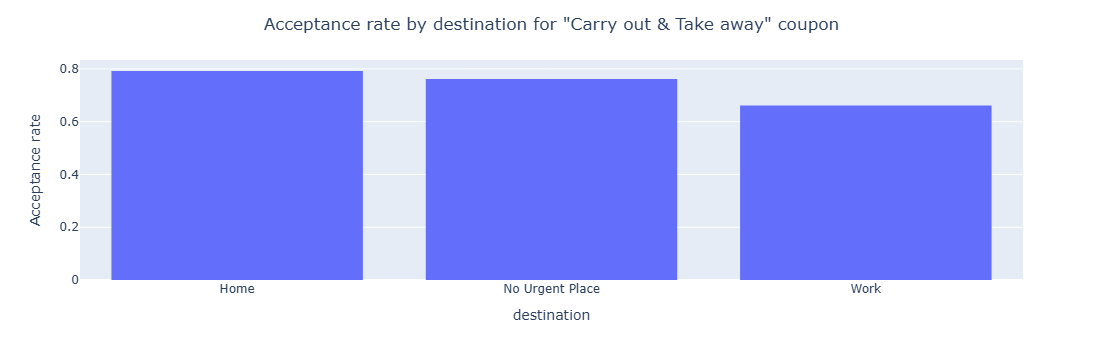

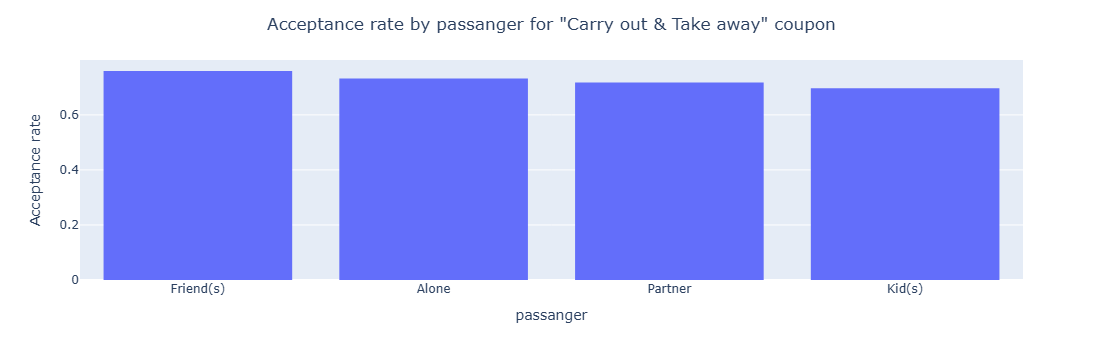

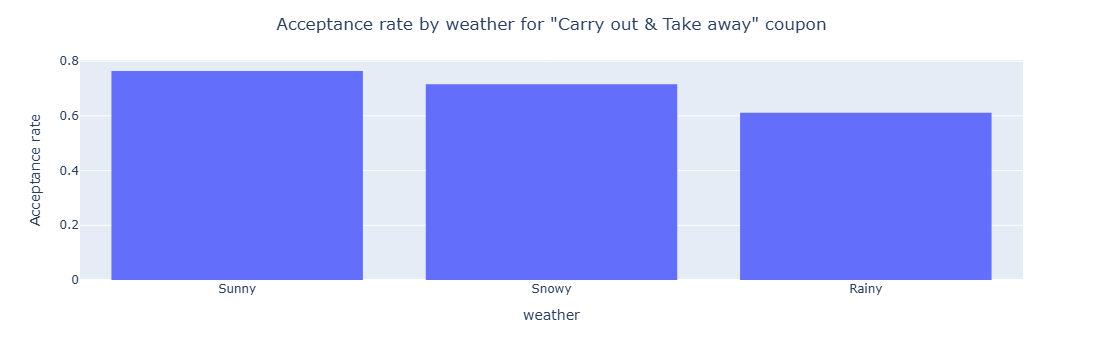

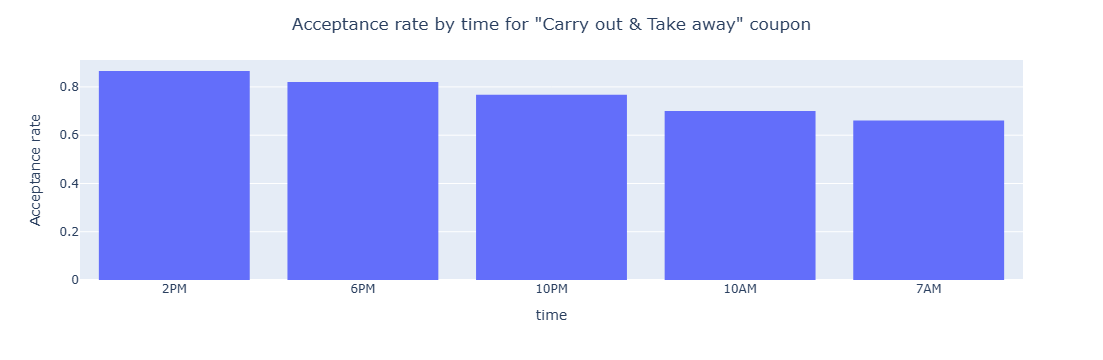

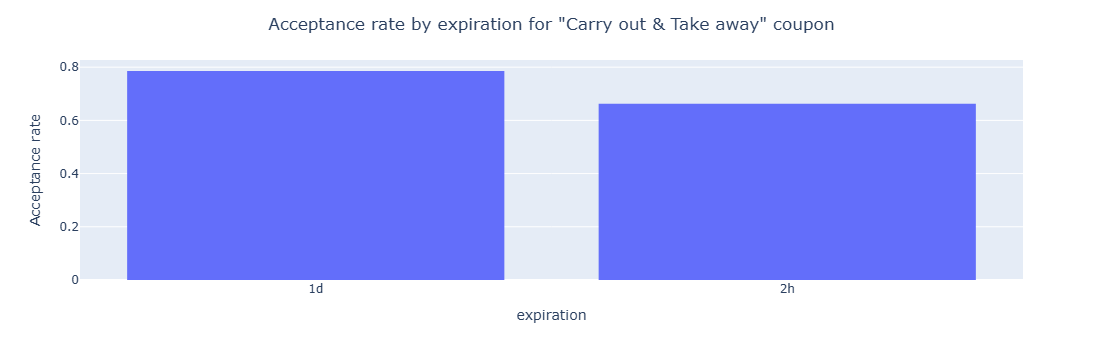

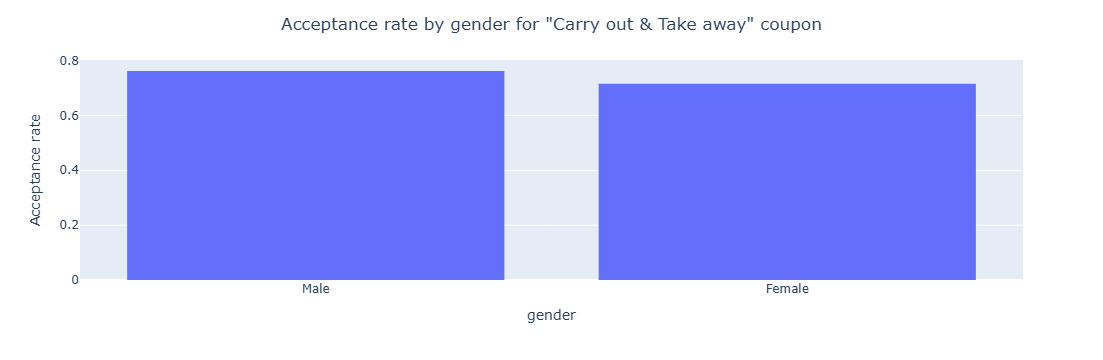

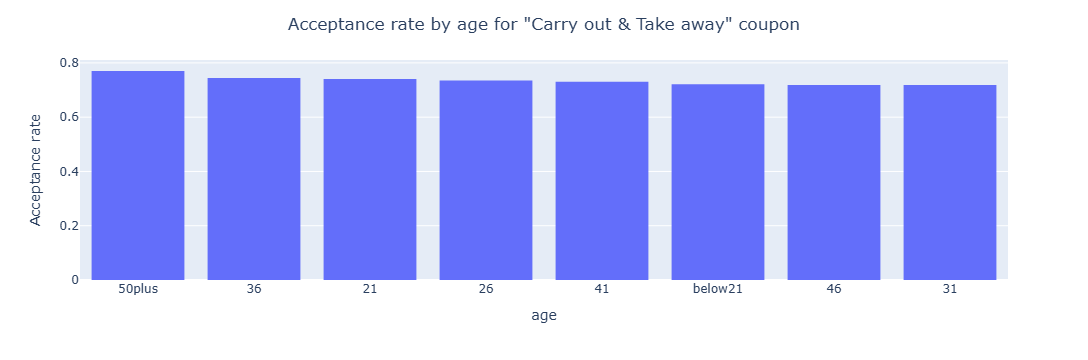

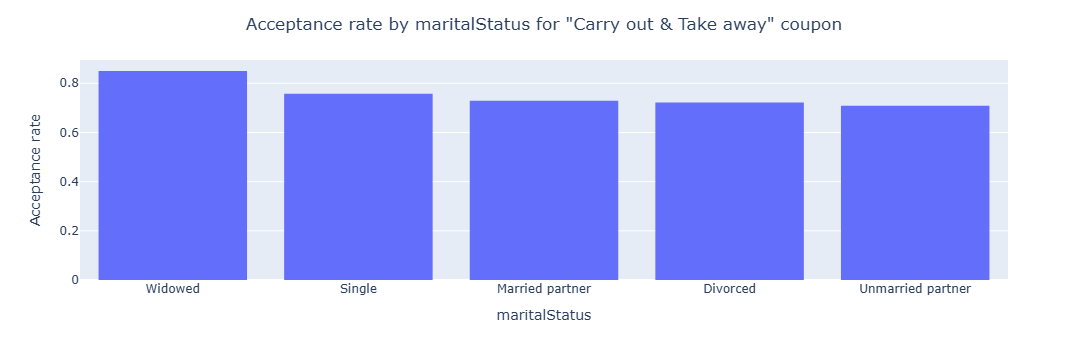

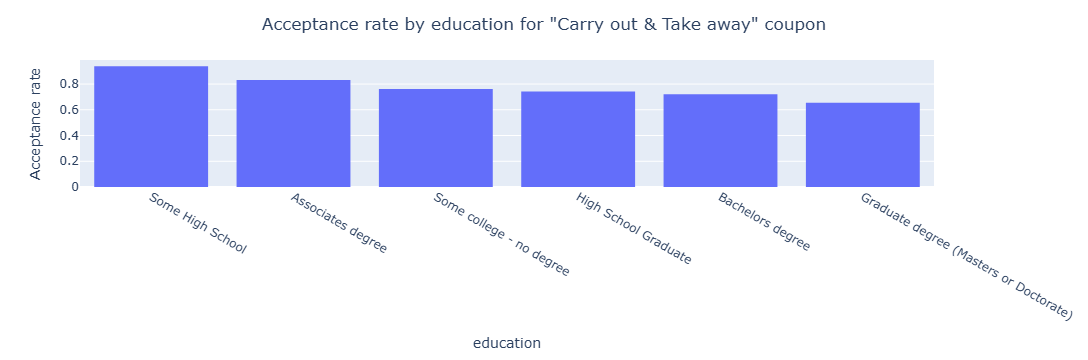

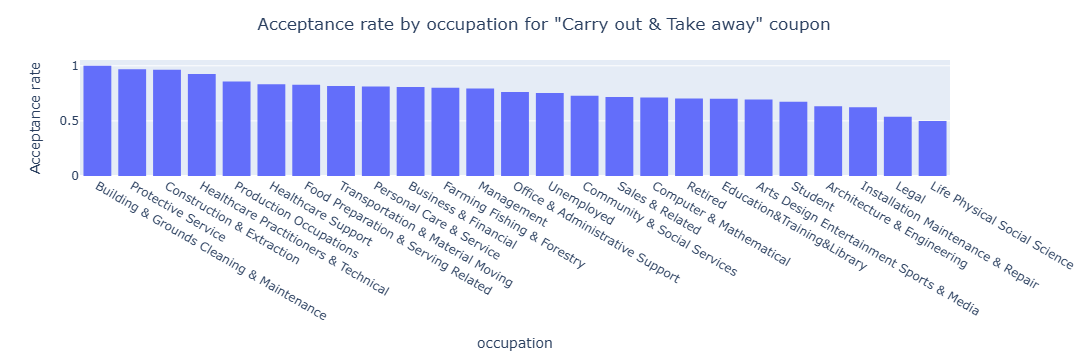

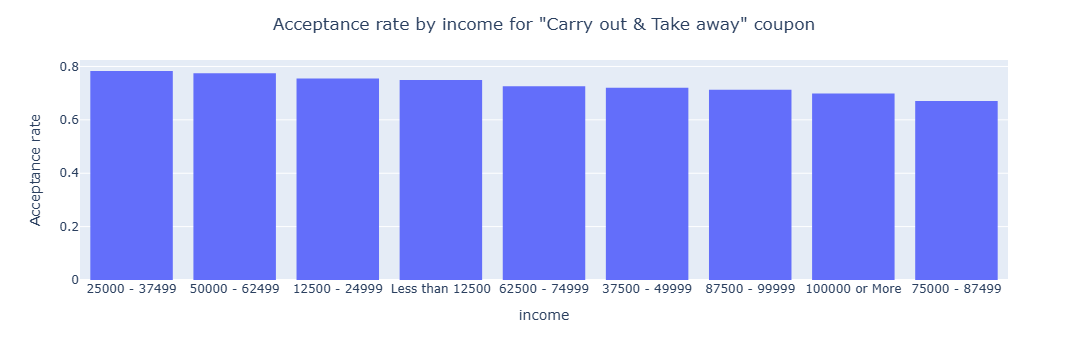

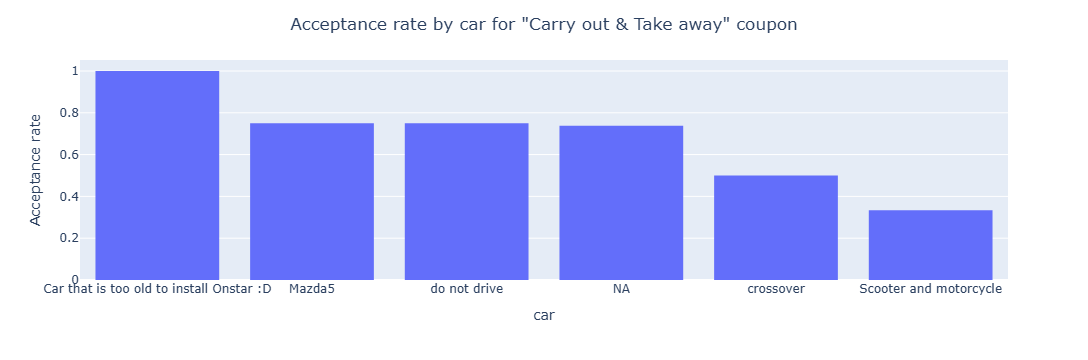

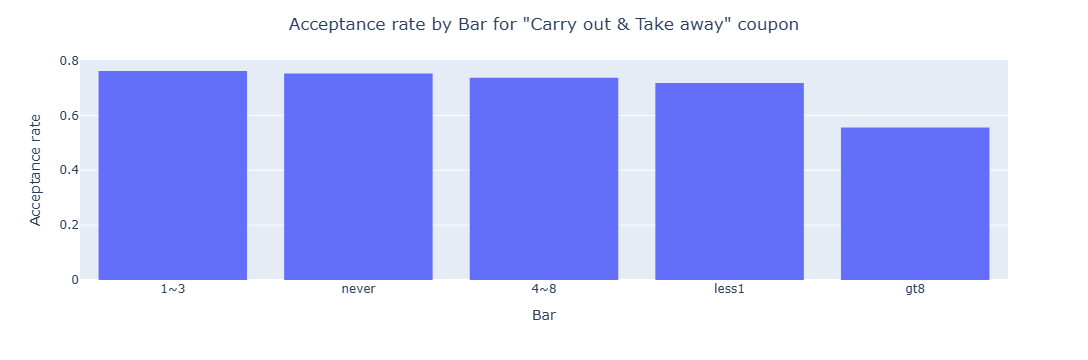

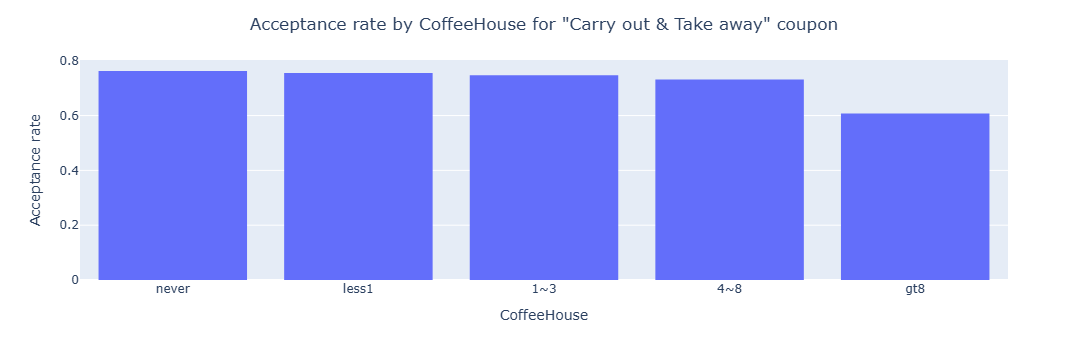

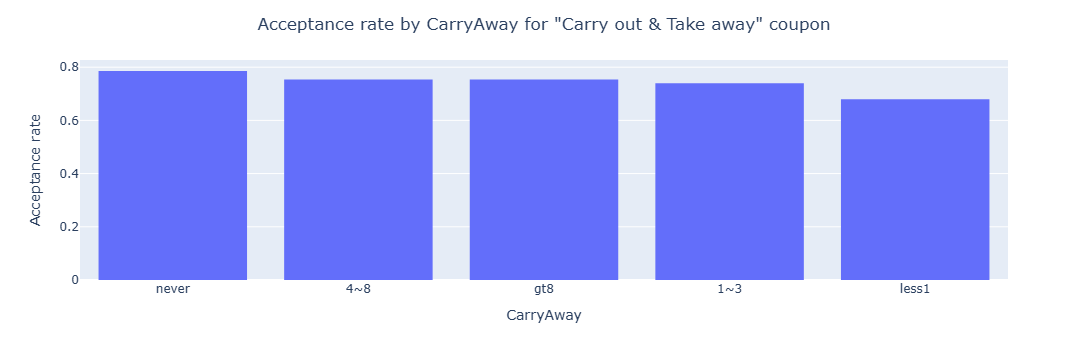

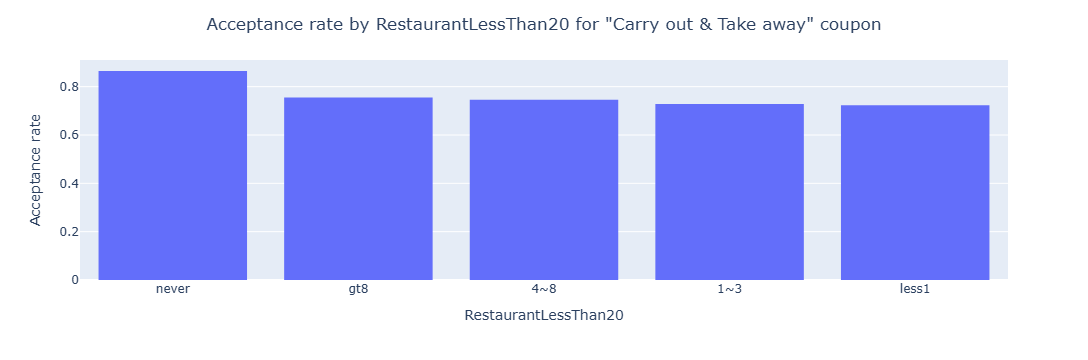

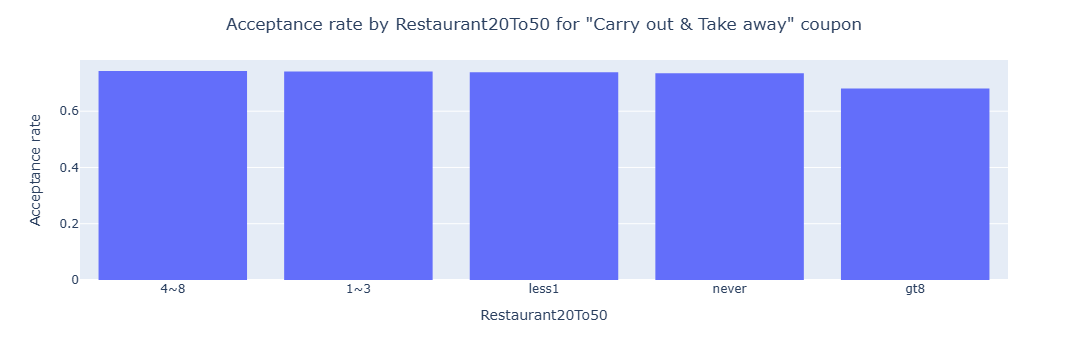

In [100]:
# 1) We create a new DataFrame that contains just the "Carry out & Take away" coupons.
data_carry = data.query('coupon == "Carry out & Take away"')
data_carry.head()

# 2) What proportion of "Carry out & Take away" coupons were accepted?
data_carry['Y'].value_counts(normalize = True)
#The proportion of "Carry out & Take away" coupons which were accepted is about 74%

# 3) Compare the acceptance rate between those who buys takeaway food 3 or fewer times a month to those who buys more.
data_carry.groupby(data_carry['CarryAway'].isin(['1~3','less1', 'never']))['Y'].value_counts(normalize = True)
# we see that the acceptance rate of those who buys takeaway food 3 or fewer times a month is about 72%
# and the acceptance rate of those who buys more is about 75%
# so the acceptance rate of those who buys takeaway food 3 or fewer times a month is about the same to those who buys more

# 4) Compare the acceptance rate of those who buys takeaway food depending on each categorical column
categorical_columns = data_carry.select_dtypes(include=['object', 'category']).columns
# we create an histogram of the acceptance rate by each of the categorical column
for col in categorical_columns:
    if col not in ['coupon']:  
        data_carry_col = data_carry.groupby([col])['Y'].value_counts(normalize = True).to_frame(name='acceptance rate').reset_index().sort_values(by = 'acceptance rate', ascending = False).query('Y == 1')
        plt_col = px.histogram(data_carry_col, x = col, y = 'acceptance rate', nbins = 10)
        plt_col.update_layout(title=f'Acceptance rate by {col} for "Carry out & Take away" coupon', yaxis_title="Acceptance rate", title_x = 0.5)
        plt_col.show()
        plt_col.write_html(f'data\\Acceptance rate by {col} for Carry out & Take away coupon.html')
# we noticed that the acceptance rate of the "Carry out & Take away" coupons is higher : 
# - for drivers who go home or to no urgent place
# - for drivers who don't travel with kid(s)
# - during Sunny or Snowy weather
# - around 2 PM and 6 PM
# - when the coupon expires before 1 day
# - for male drivers
# - for drivers who are 50 years old or more
# - for widowed drivers
# - for drivers with lower level of education or with lower income
# - for drivers in the occupation of : Building & grounds cleaning & maintenance, protective services, construction & extraction, healthcare practitioners & technical
# - for drivers who don't go more than 8 times a month to Bars or Coffehouses
# - for drivers who never buy takeaway food or never go to cheap restaurants

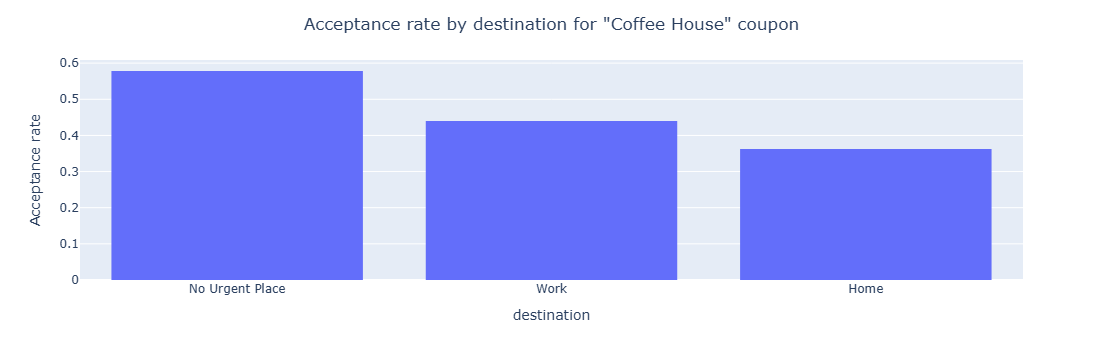

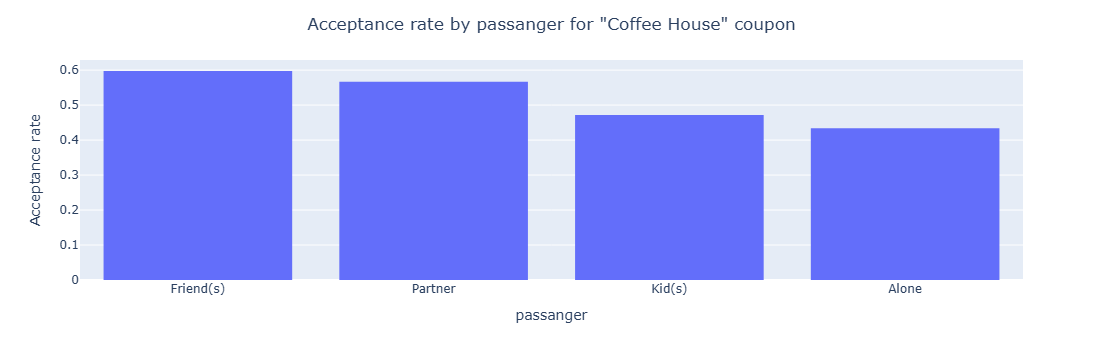

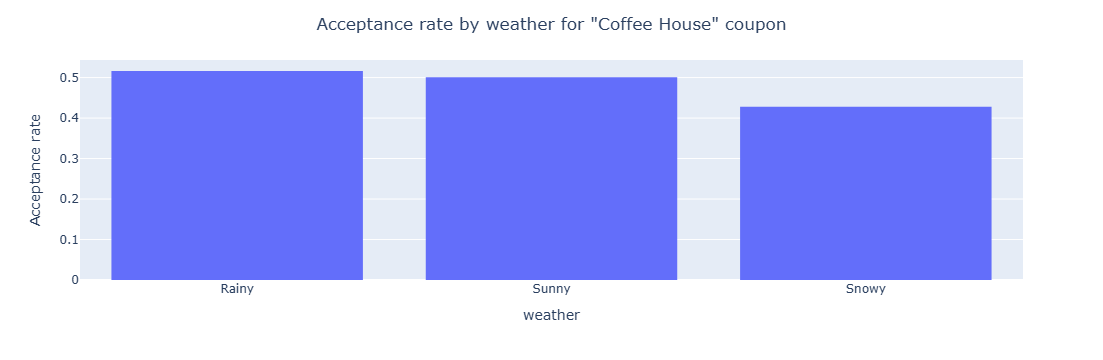

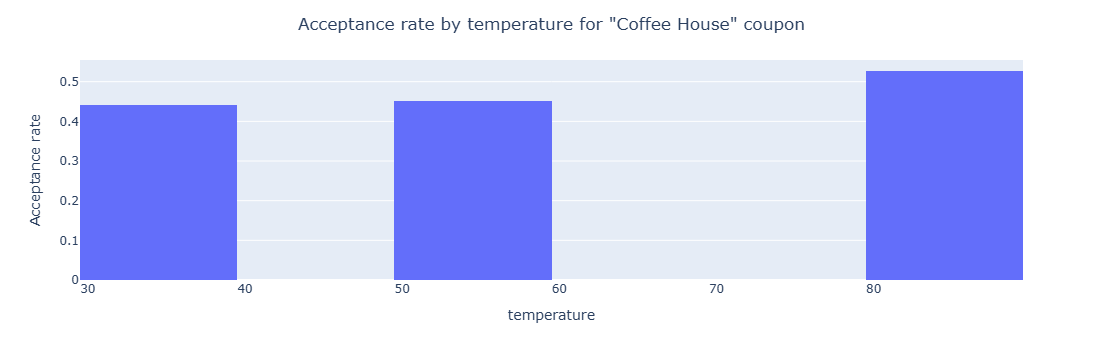

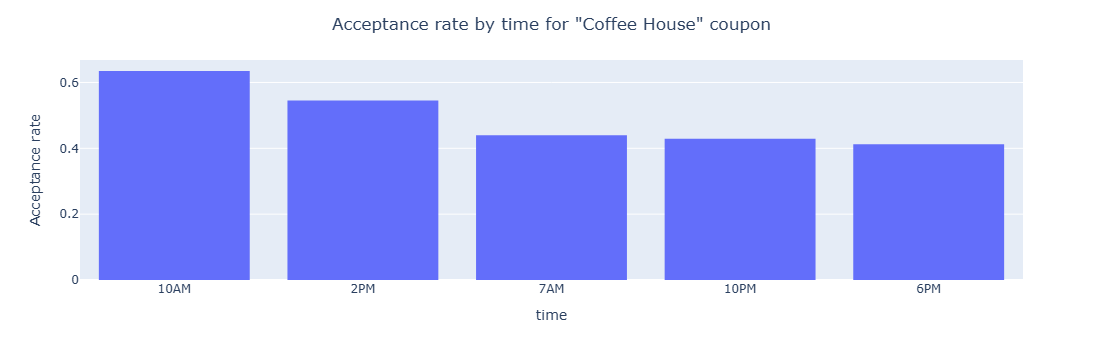

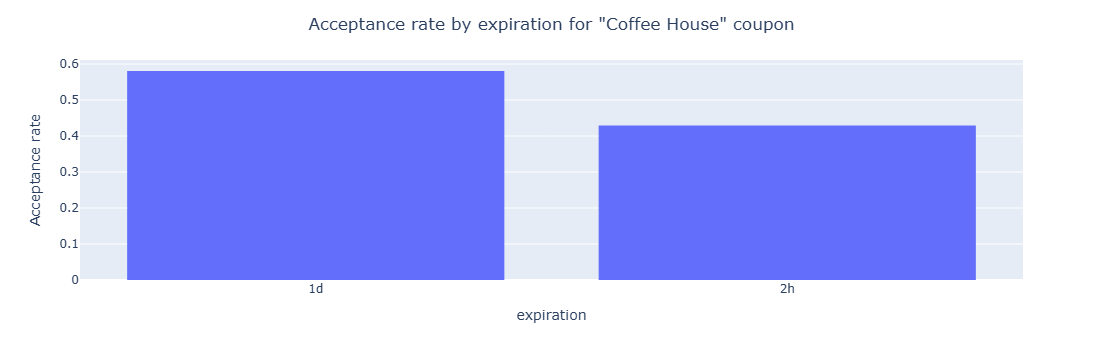

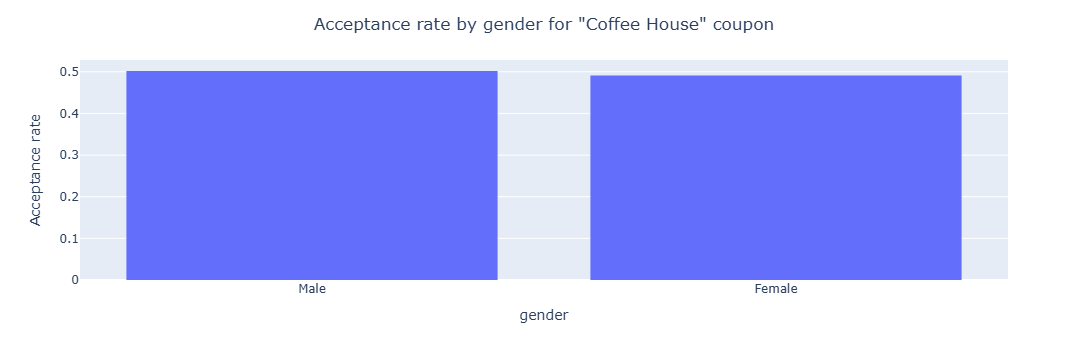

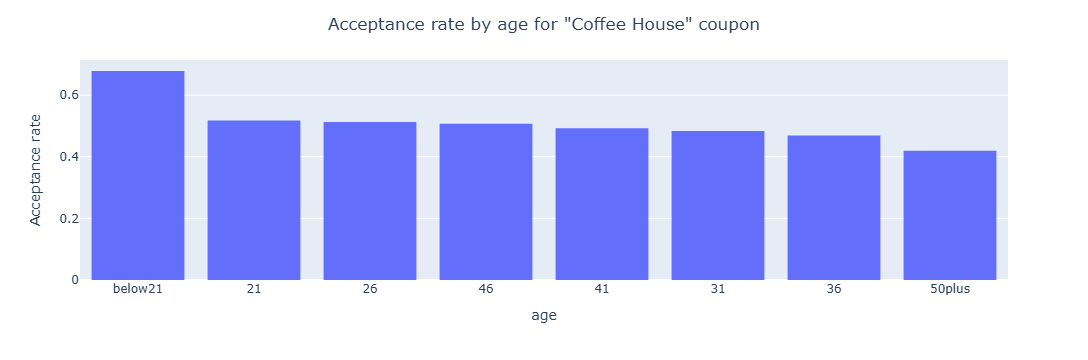

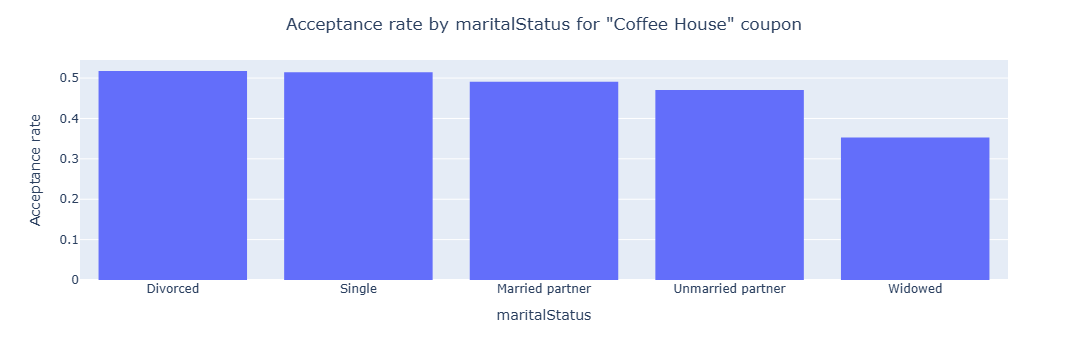

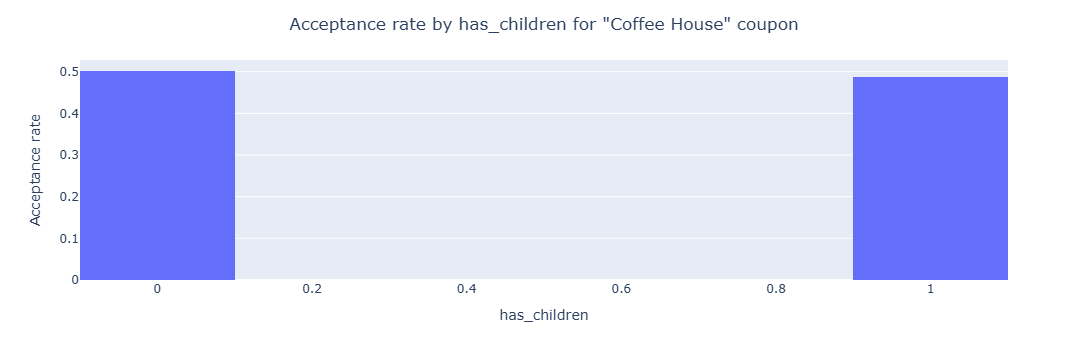

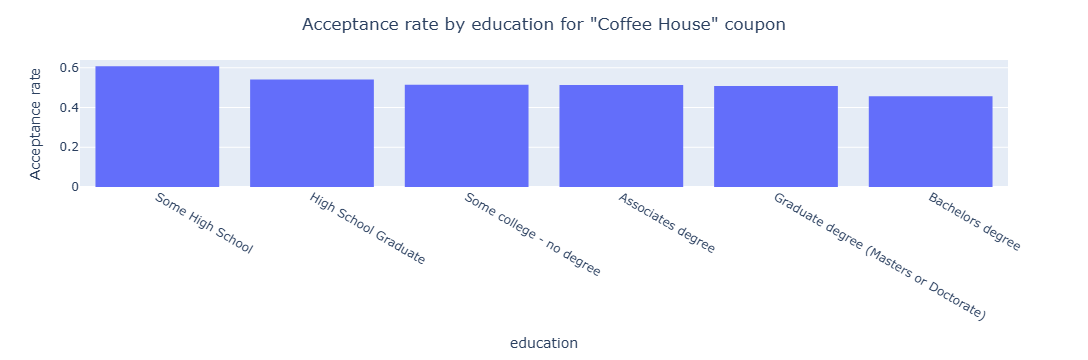

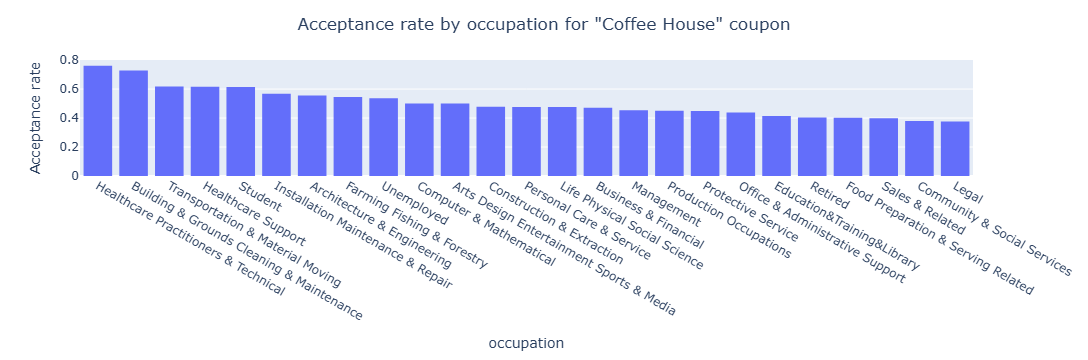

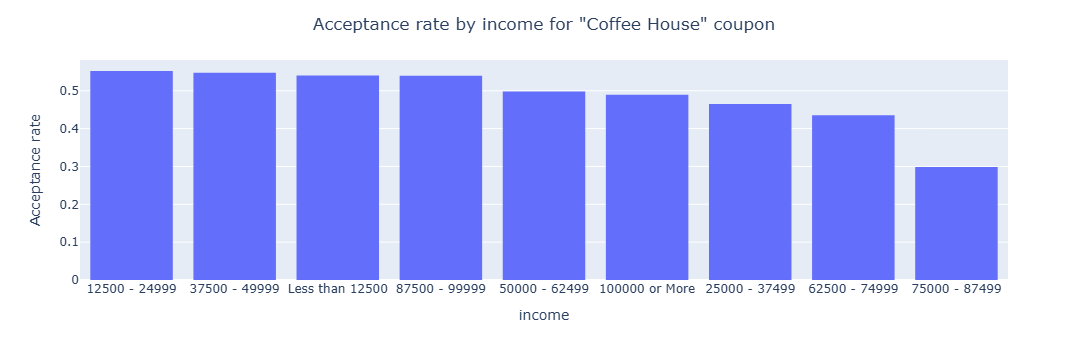

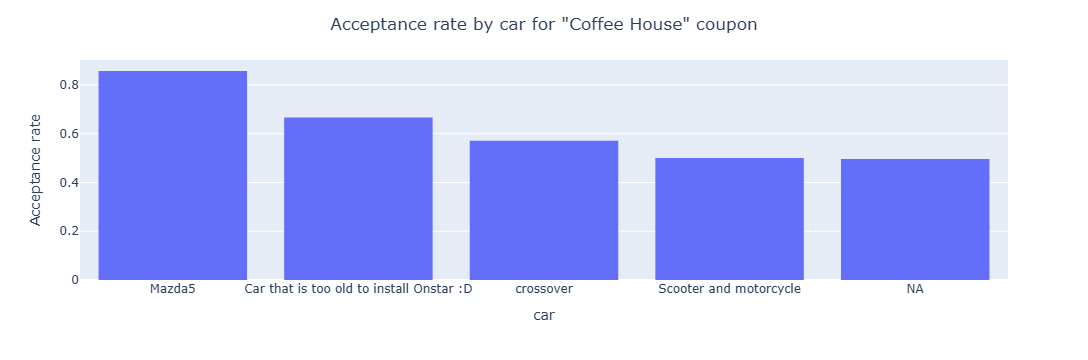

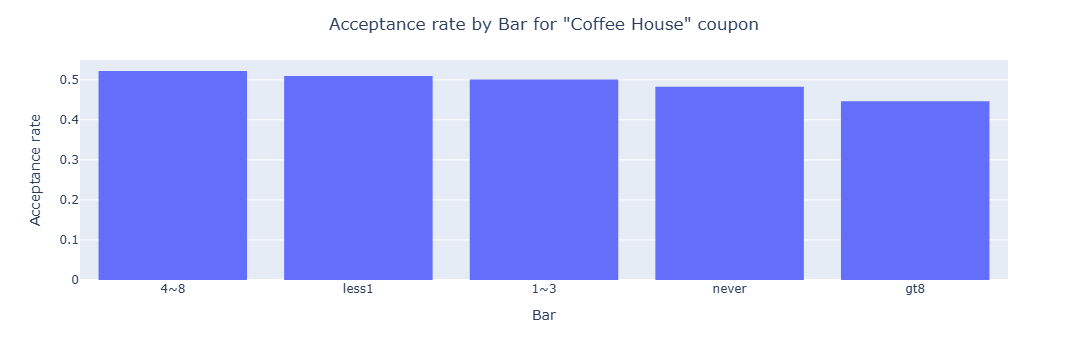

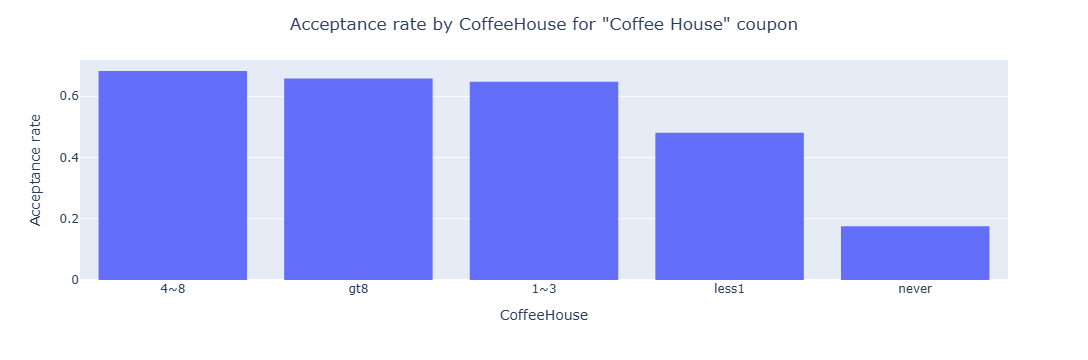

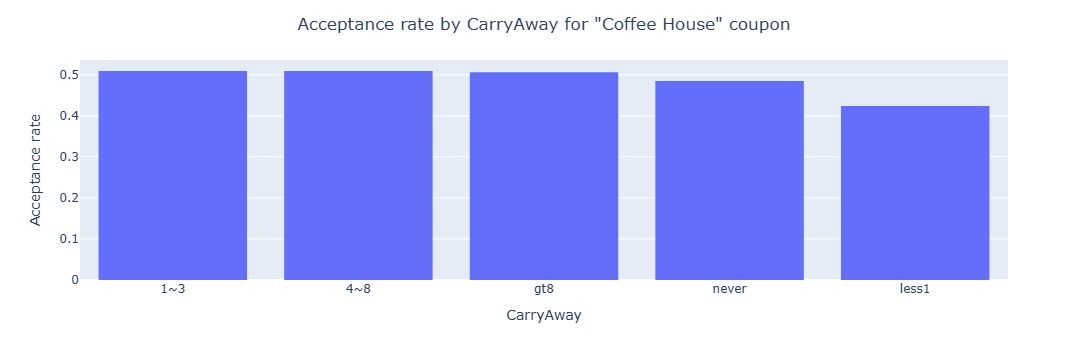

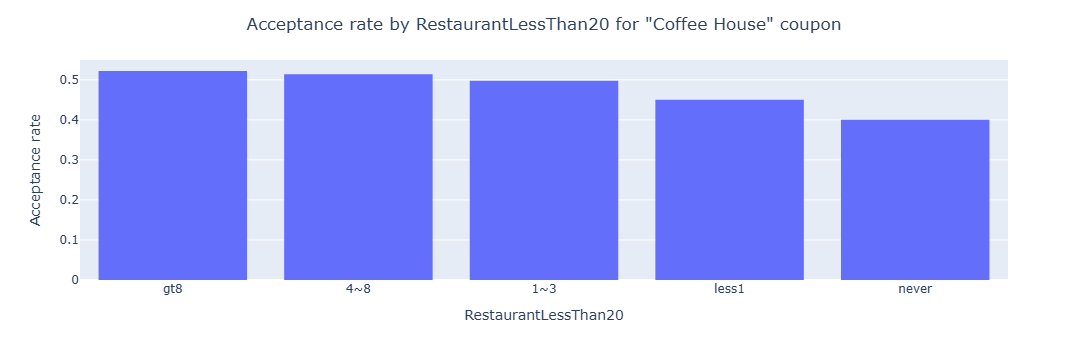

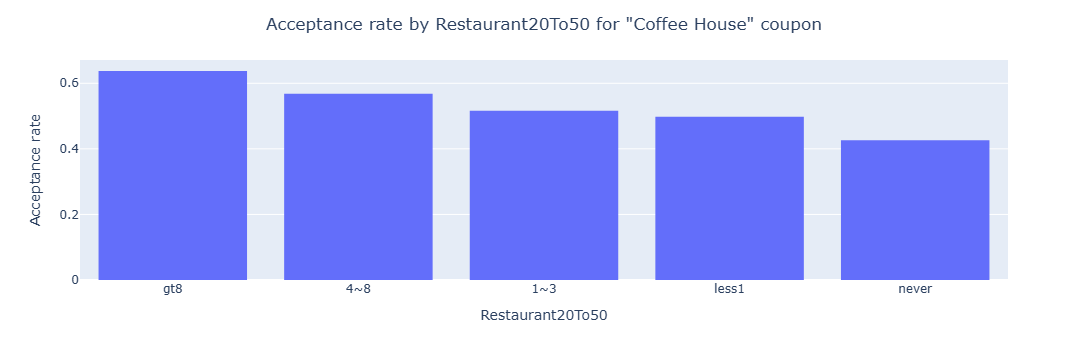

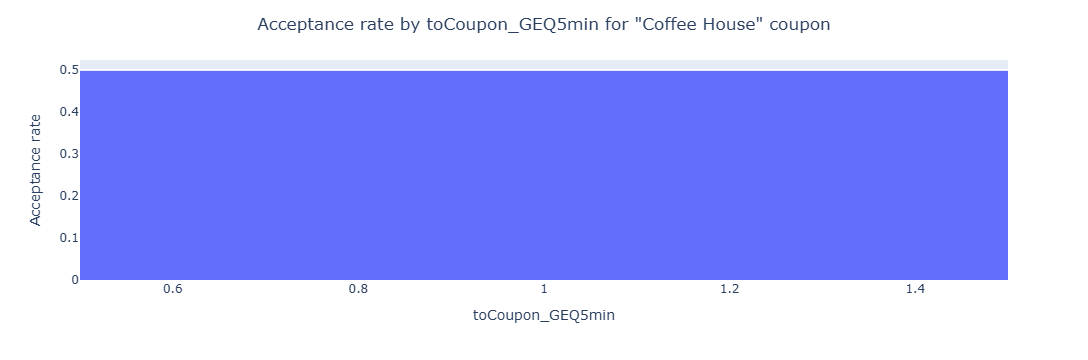

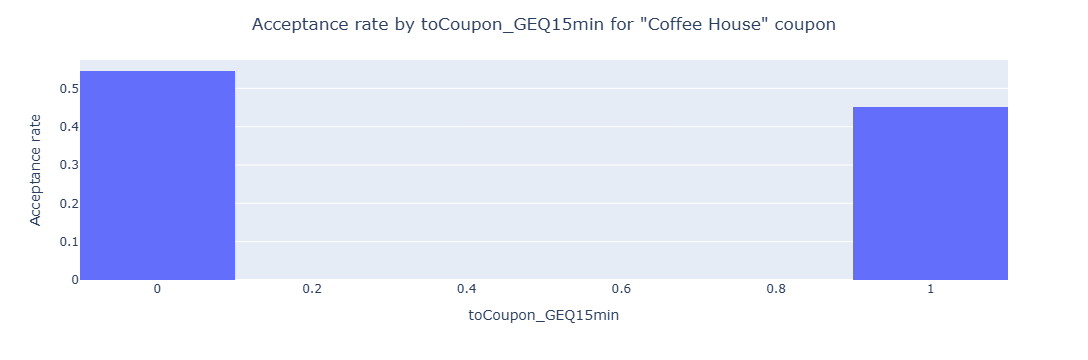

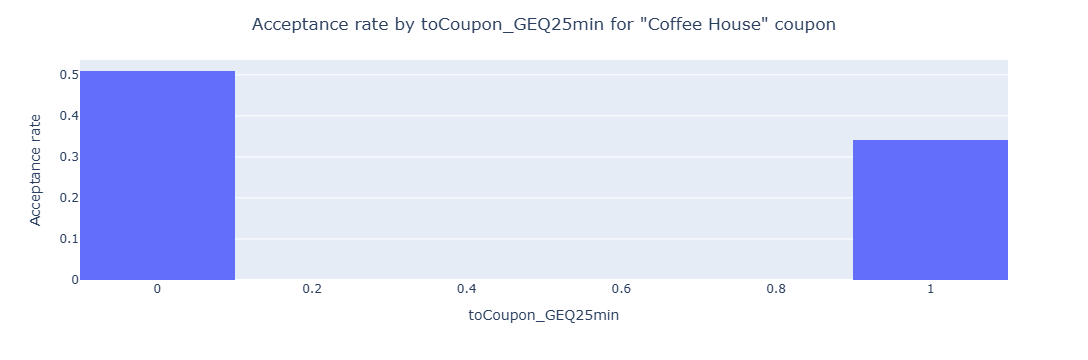

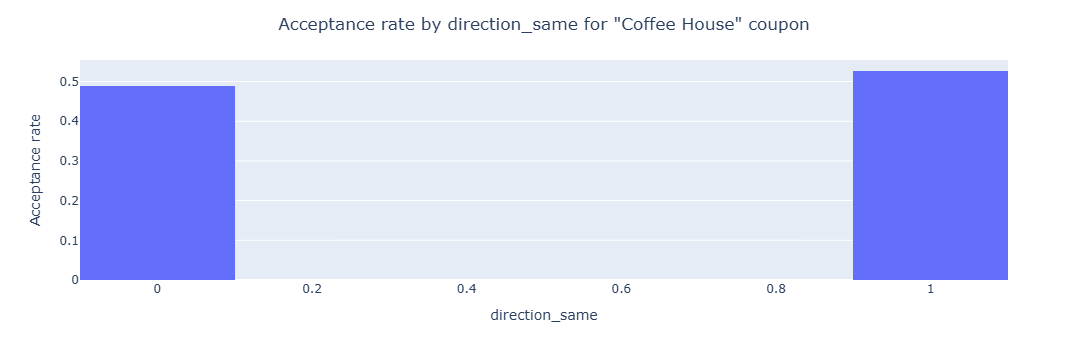

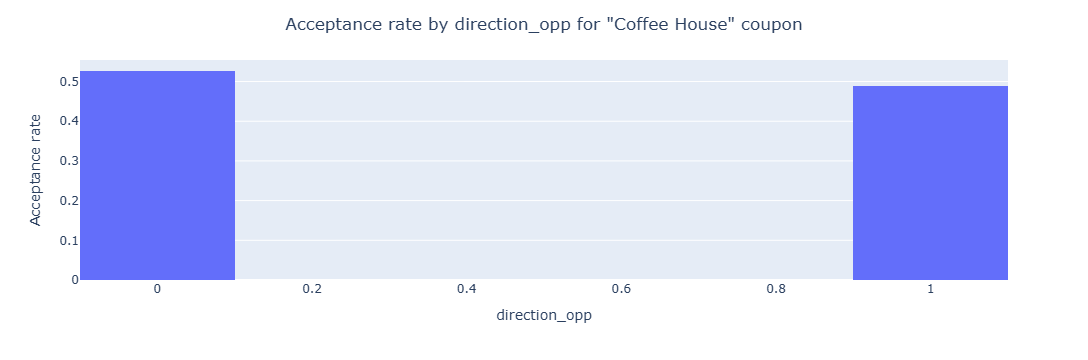

In [101]:
# 1) We create a new DataFrame that contains just the "Coffee House" coupons.

data_coffee = data.query('coupon == "Coffee House"')
data_coffee.head()

# 2) What proportion of "Coffee House" coupons were accepted?

data_coffee['Y'].value_counts(normalize = True)
#The proportion of "Coffee House" coupons which were accepted is about 50%

# 3) Compare the acceptance rate between those who go to a coffee house 3 or fewer times a month to those who go more.
data_coffee.groupby(data_coffee['CoffeeHouse'].isin(['1~3','less1', 'never']))['Y'].value_counts(normalize = True)
# we see that the acceptance rate of those who go to a coffee house 3 or fewer times a month is about 45%
# and the acceptance rate of those who go more is about 67%
# so the acceptance rate of those who go to a coffee 3 or fewer times a month is a lot less than those who go more

# 4) Compare the acceptance rate of those who go to Coffehouses depending on each categorical column
categorical_columns = data_coffee.select_dtypes(include=['object', 'category', 'int64']).columns
# we create an histogram of the acceptance rate by each of the categorical column
for col in categorical_columns:
    if col not in ['coupon', 'Y']:  
        data_coffee_col = data_coffee.groupby([col])['Y'].value_counts(normalize = True).to_frame(name='acceptance rate').reset_index().sort_values(by = 'acceptance rate', ascending = False).query('Y == 1')
        plt_col = px.histogram(data_coffee_col, x = col, y = 'acceptance rate', nbins = 10)
        plt_col.update_layout(title=f'Acceptance rate by {col} for "Coffee House" coupon', yaxis_title="Acceptance rate", title_x = 0.5)
        plt_col.show()
        plt_col.write_html(f'data\\Acceptance rate by {col} for Coffee House coupon.html')
# we noticed that the acceptance rate of the "Coffe House" coupons is higher : 
# - for drivers who go to no urgent place
# - for drivers who travel with friend(s) or partner
# - during Rainy or Sunny weather
# - when the temperature is hot
# - around 10 AM
# - when the coupon expires before 1 day
# - for drivers who are below 21 years old
# - for non-widowed drivers
# - for drivers with lower level of education or lower income
# - for drivers in the occupation of : Healthcare practitioners & technical, Building & grounds cleaning & maintenance
# - for drivers who drive a Mazda5
# - for drivers who don't go more than 8 times a month to Bars
# - for drivers who go at least 3 times a month to Coffee Houses
# - for drivers who go order at least once a month Take away food      
# - for drivers who go at least once a month to cheap or expensive restaurants

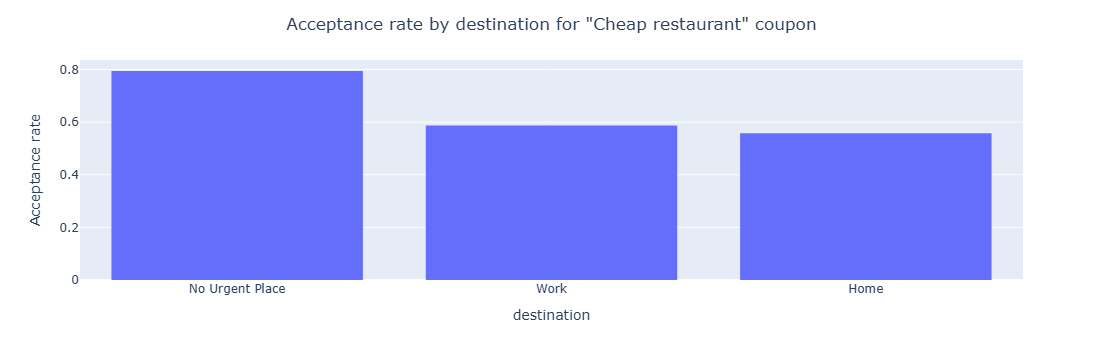

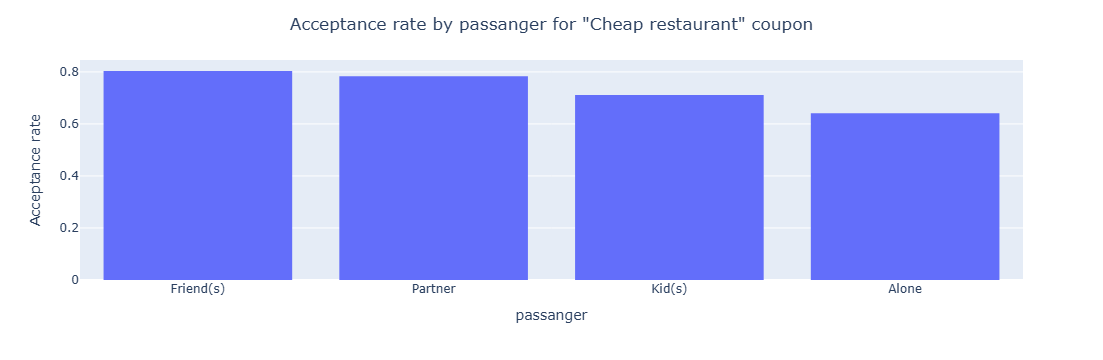

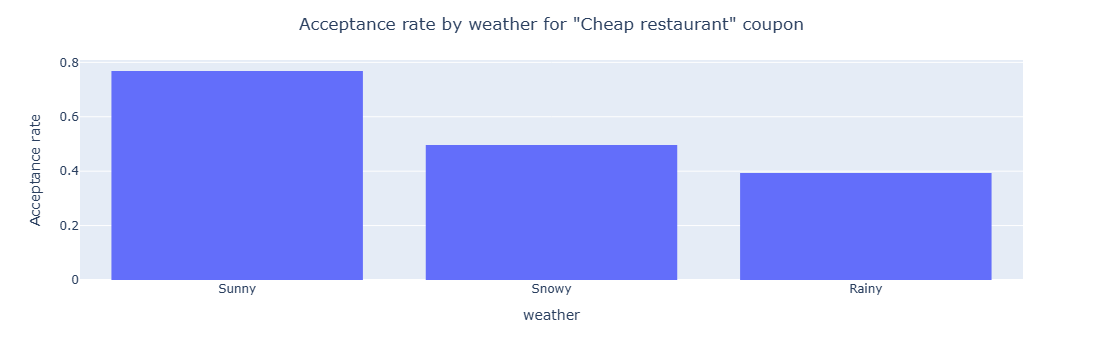

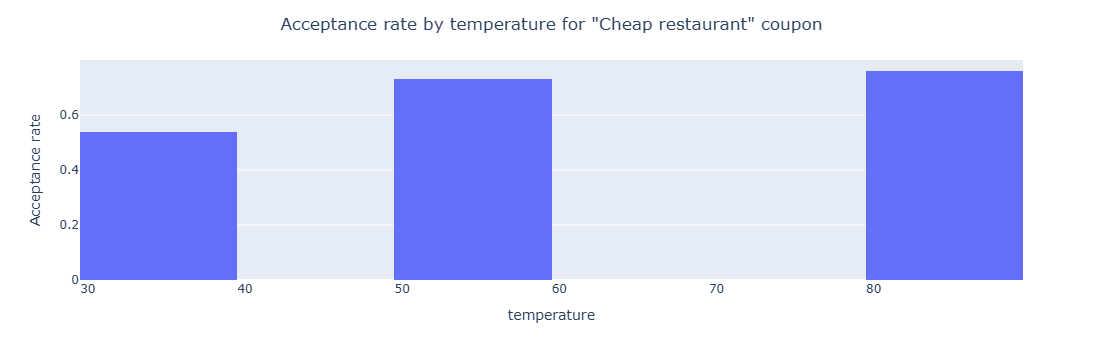

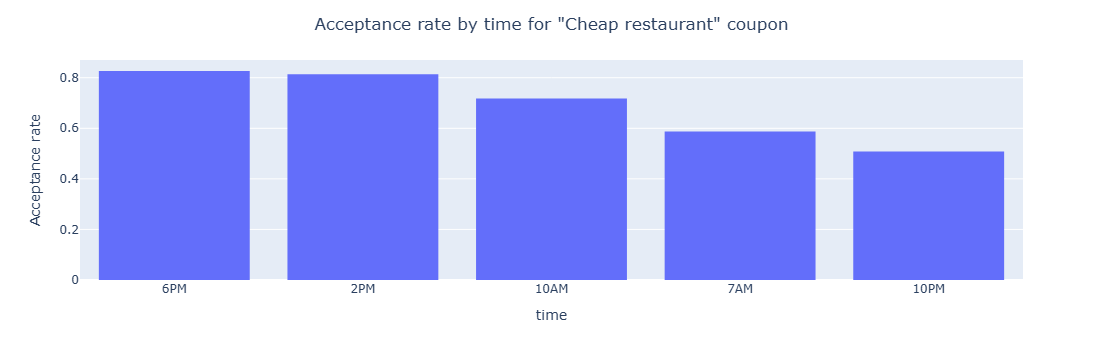

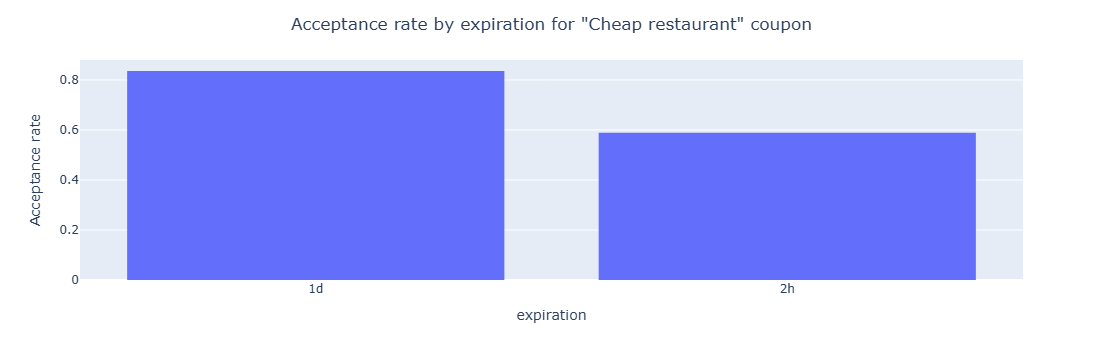

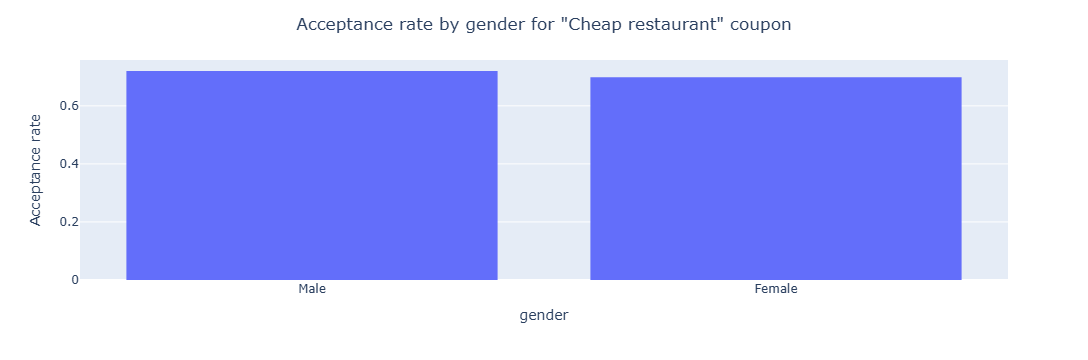

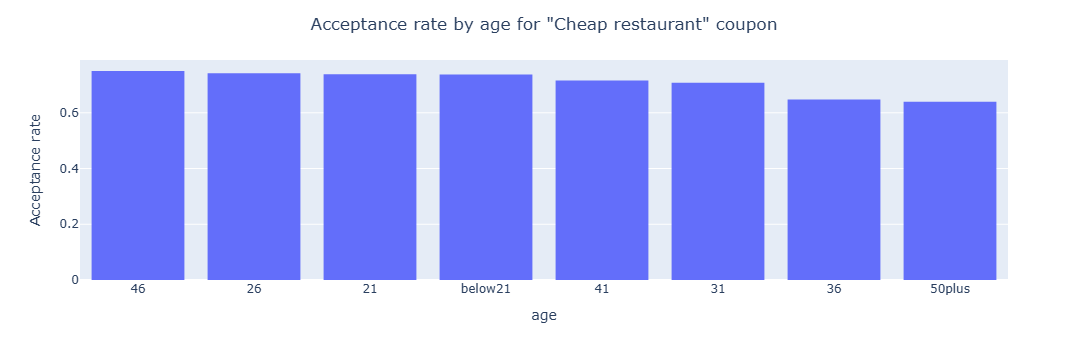

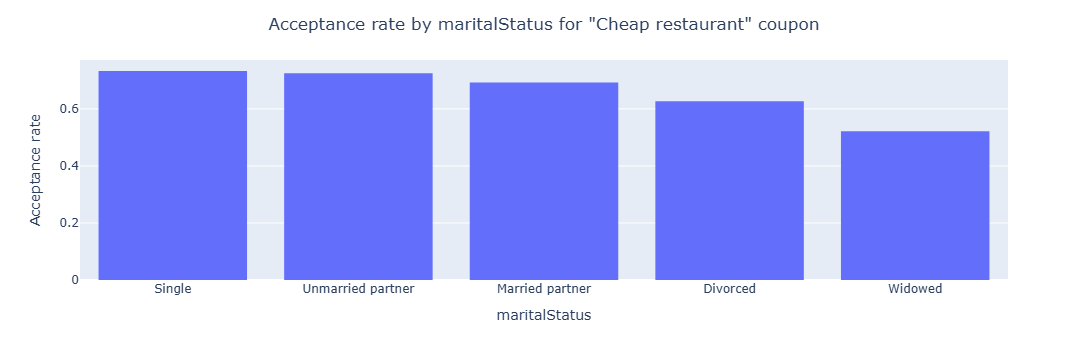

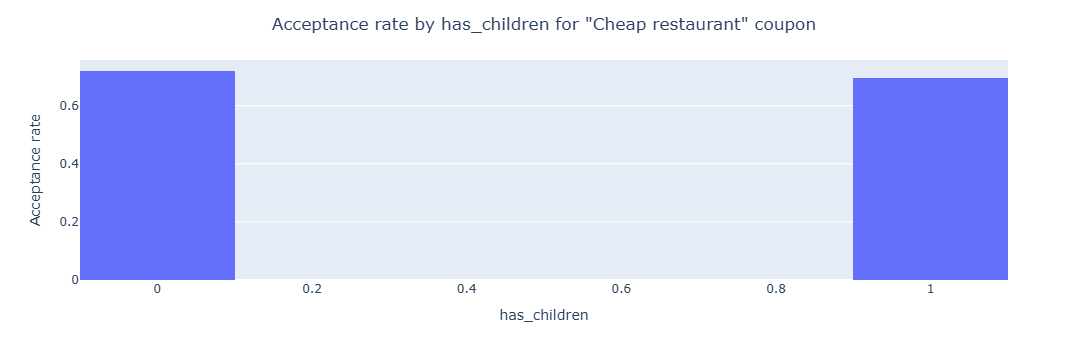

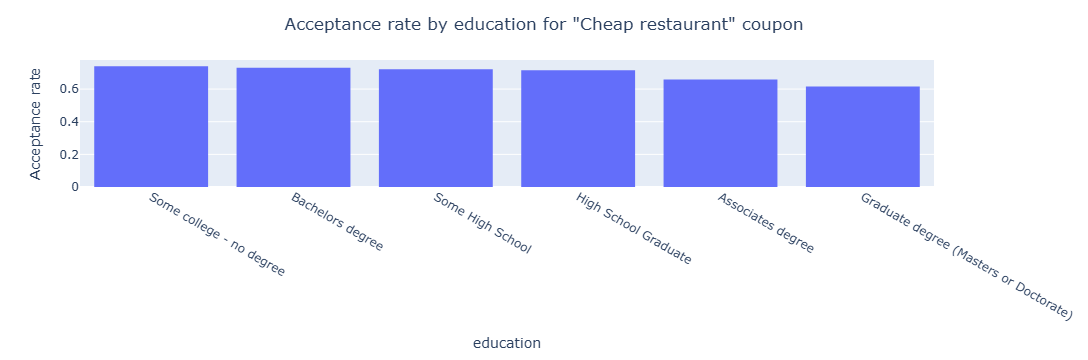

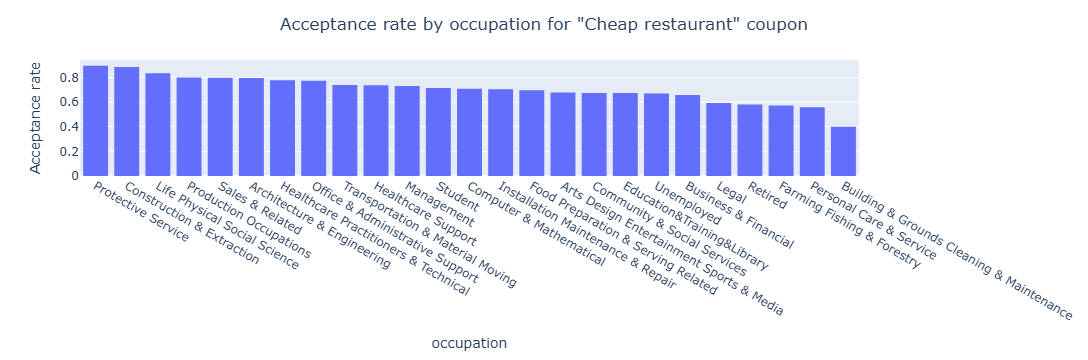

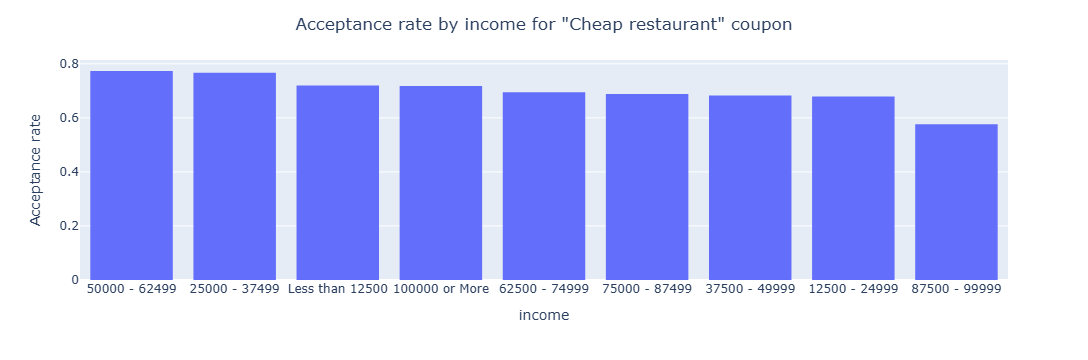

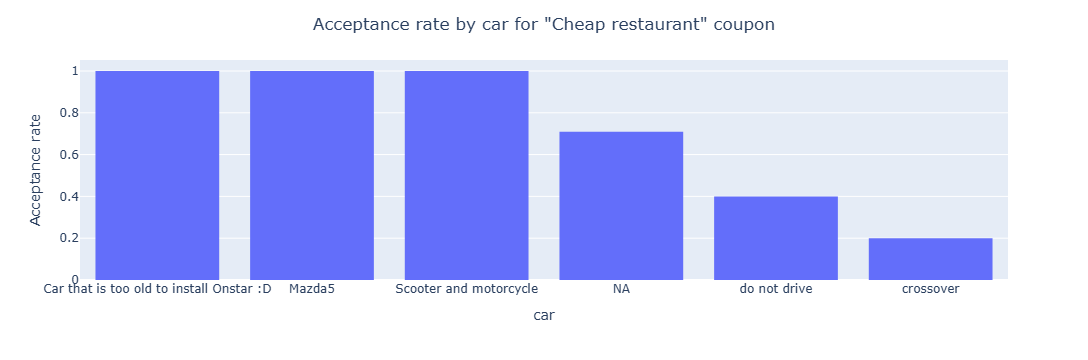

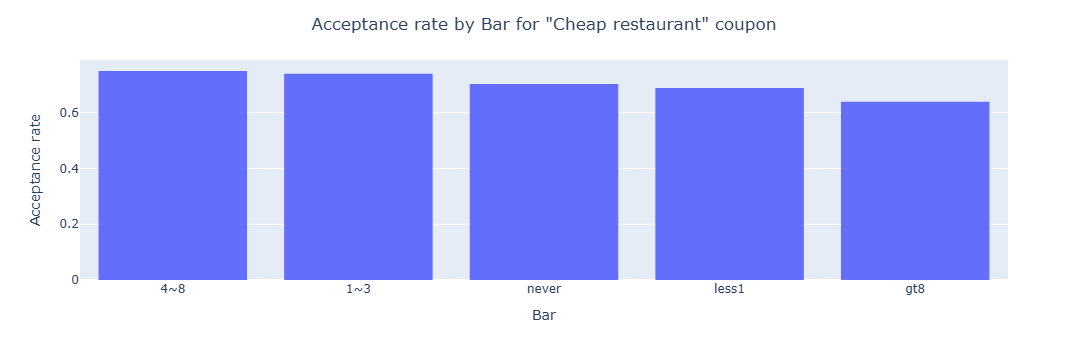

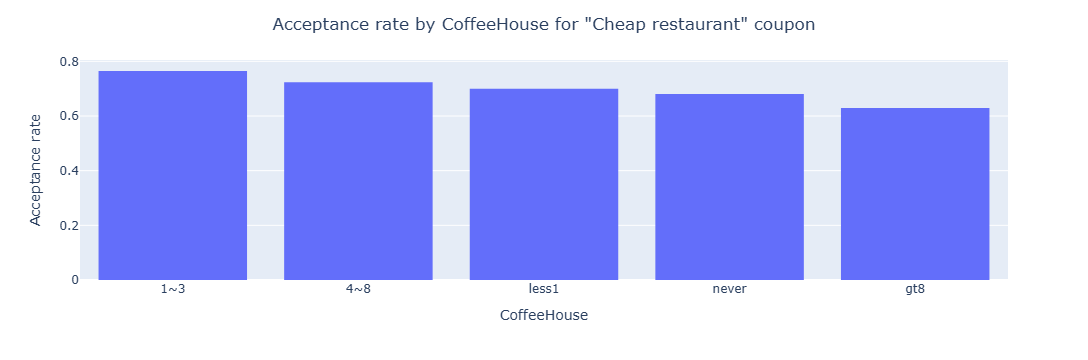

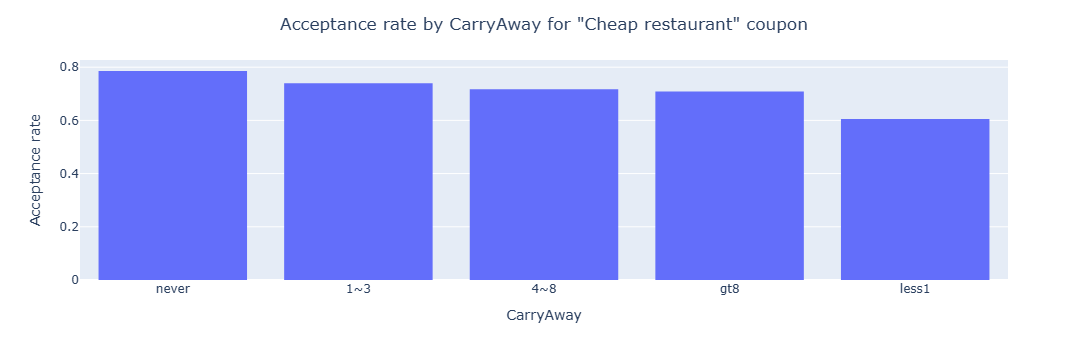

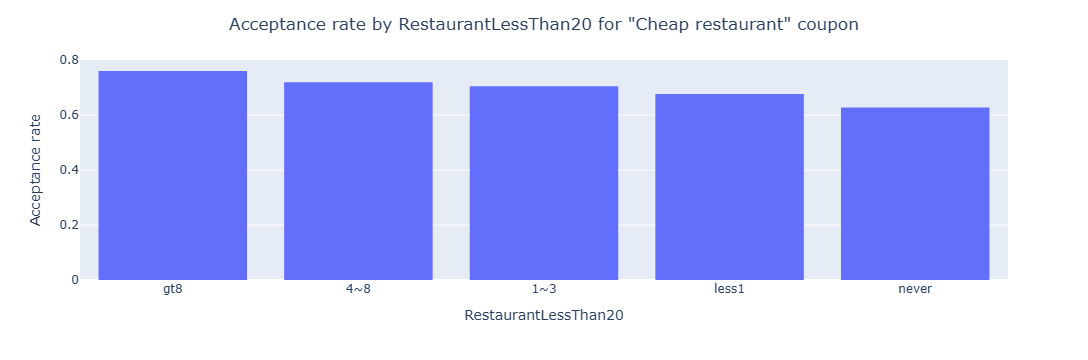

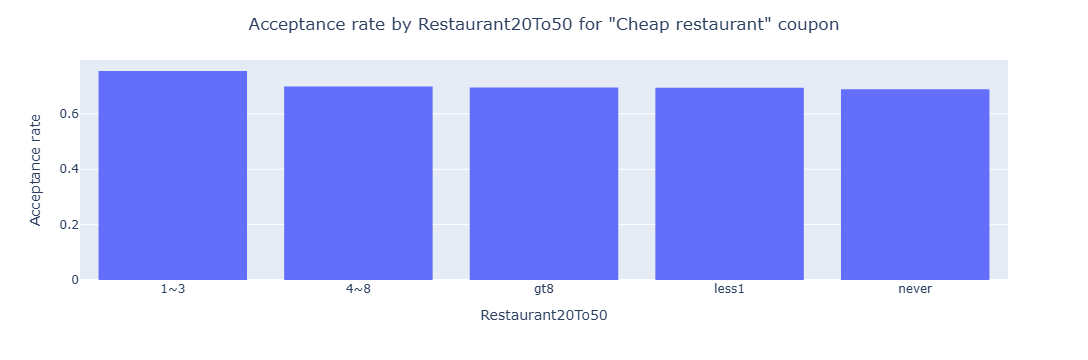

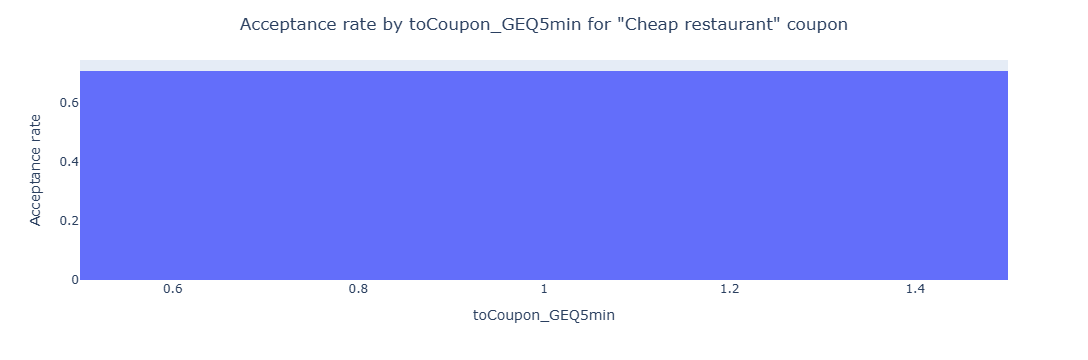

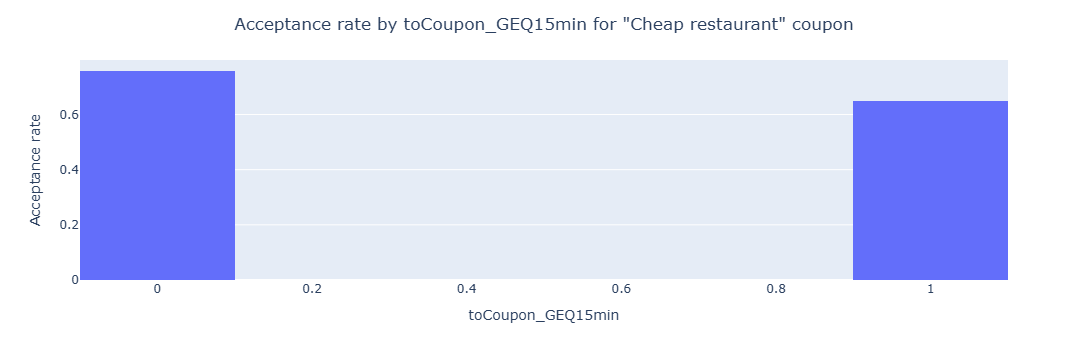

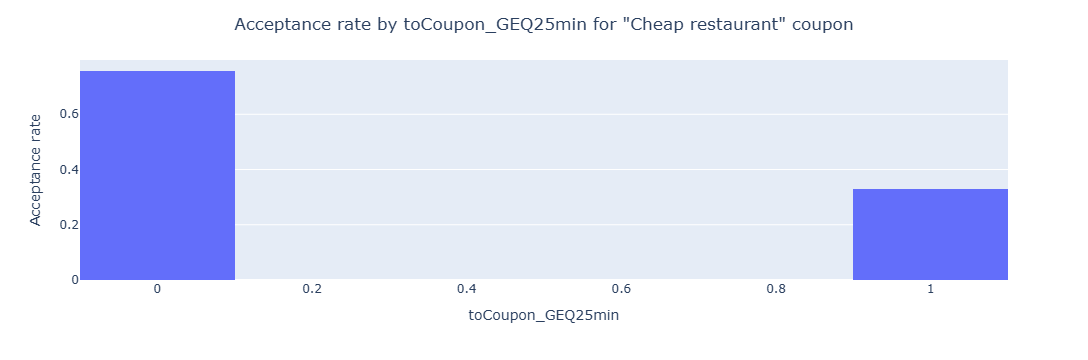

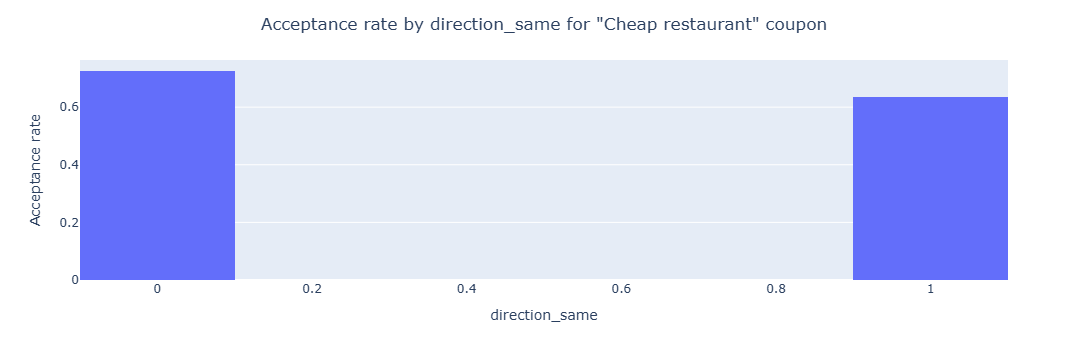

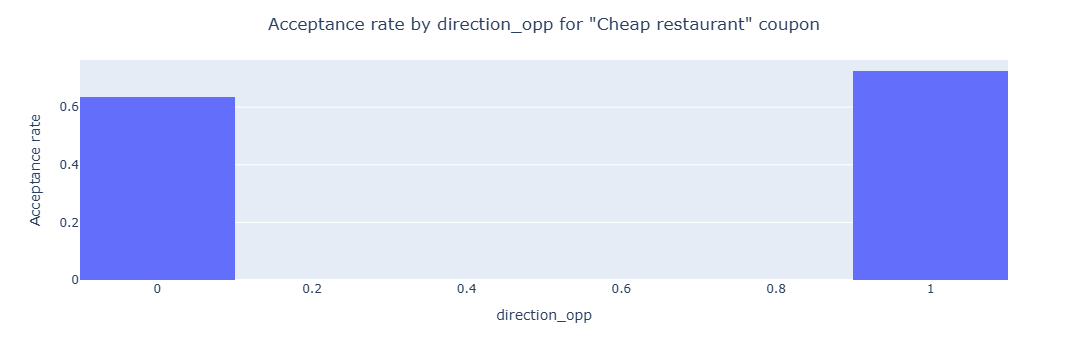

In [102]:
# 1) We create a new DataFrame that contains just the "Restaurant(<20)" coupons.

data_restaurant_cheap = data.query('coupon == "Restaurant(<20)"')
data_restaurant_cheap.head()

# 2) What proportion of "Restaurant(<20)" coupons were accepted?

data_restaurant_cheap['Y'].value_counts(normalize = True)
#The proportion of "Restaurant(<20)" coupons which were accepted is about 71%

# 3) Compare the acceptance rate between those who go to a cheap restaurant 3 or fewer times a month to those who go more.
data_restaurant_cheap.groupby(data_restaurant_cheap['RestaurantLessThan20'].isin(['1~3','less1', 'never']))['Y'].value_counts(normalize = True)
# we see that the acceptance rate of those who go to a cheap restaurant 3 or fewer times a month is about 69%
# and the acceptance rate of those who go more is about 73%
# so the acceptance rate of those who go to a cheap restaurant 3 or fewer times a month is a little bit less than those who go more

# 4) Compare the acceptance rate of those who go to a cheap restaurant depending on each categorical column
categorical_columns = data_restaurant_cheap.select_dtypes(include=['object', 'category', 'int64']).columns
# we create an histogram of the acceptance rate by each of the categorical column
for col in categorical_columns:
    if col not in ['coupon', 'Y']:  
        data_restaurant_cheap_col = data_restaurant_cheap.groupby([col])['Y'].value_counts(normalize = True).to_frame(name='acceptance rate').reset_index().sort_values(by = 'acceptance rate', ascending = False).query('Y == 1')
        plt_col = px.histogram(data_restaurant_cheap_col, x = col, y = 'acceptance rate', nbins = 10)
        plt_col.update_layout(title=f'Acceptance rate by {col} for "Cheap restaurant" coupon', yaxis_title="Acceptance rate", title_x = 0.5)
        plt_col.show()
        plt_col.write_html(f'data\\Acceptance rate by {col} for Cheap restaurant coupon.html')
# we noticed that the acceptance rate of the "Restaurant(<20)" coupons is higher : 
# - for drivers who go to no urgent place
# - for drivers who travel with friend(s) or partner
# - during Sunny weather
# - when it is not too cold
# - around 6PM or 2PM
# - when the coupon expires before 1 day
# - for drivers who are less than 50 years old
# - for non-widowed drivers
# - for drivers in the occupation of : Protective Service, Construction & extraction, Life Physical Social science, Production occupations
# - for drivers who don't go more than 8 times a month to Bars or Coffee Houses
# - for drivers who never order takeawy food      
# - for drivers who go at least 4 times a month to cheap restaurants
# - for drivers who go at least once a month to expensive restaurants
# - when the geographical distance doesn't exceed 25 minutes drive

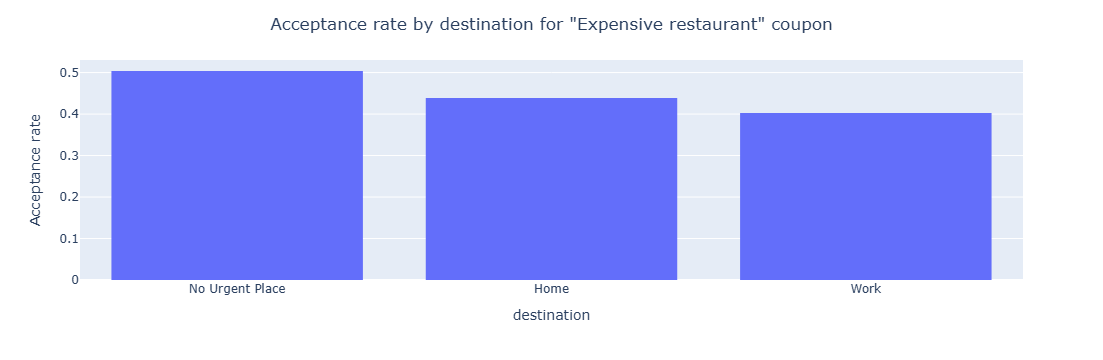

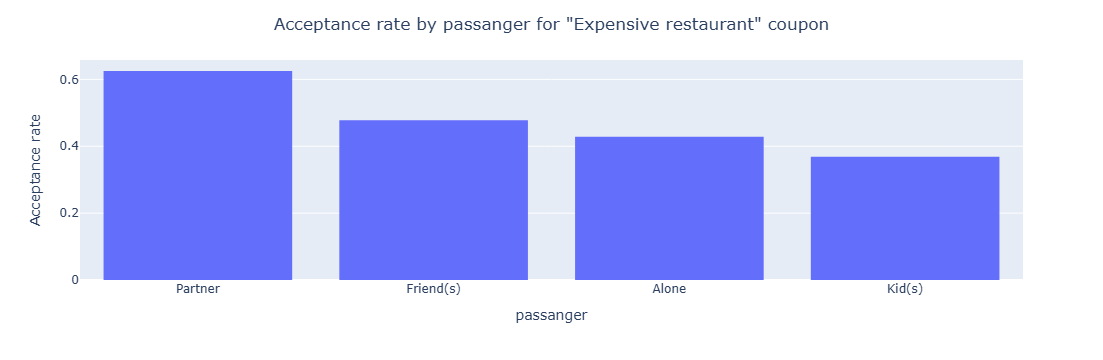

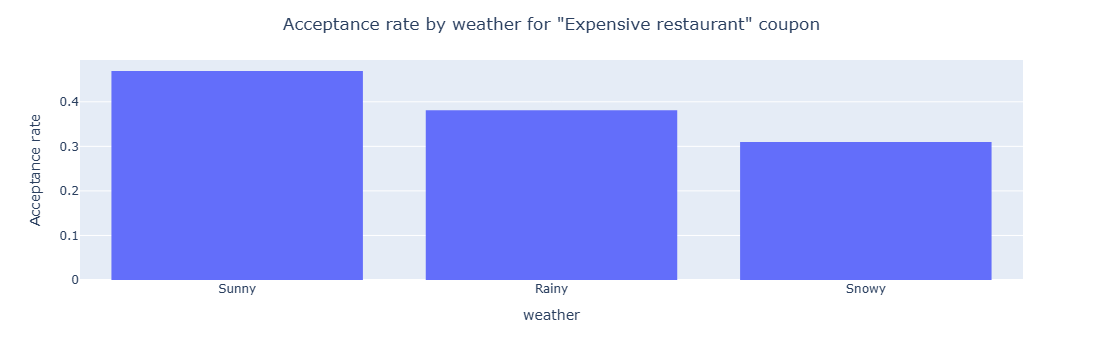

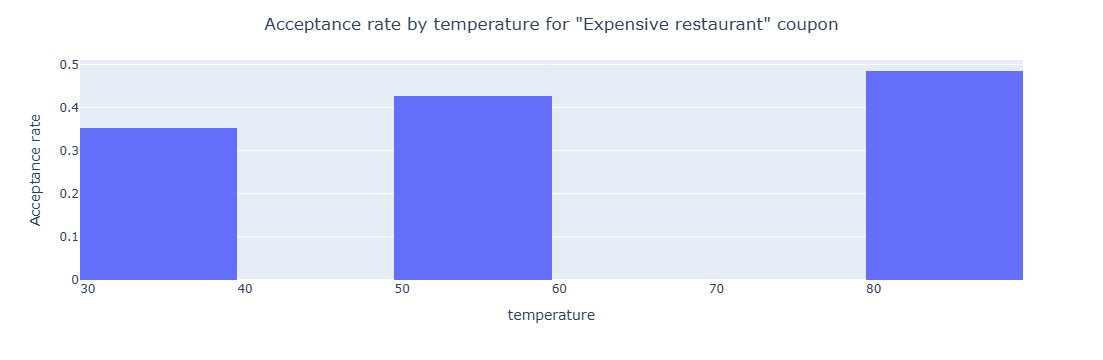

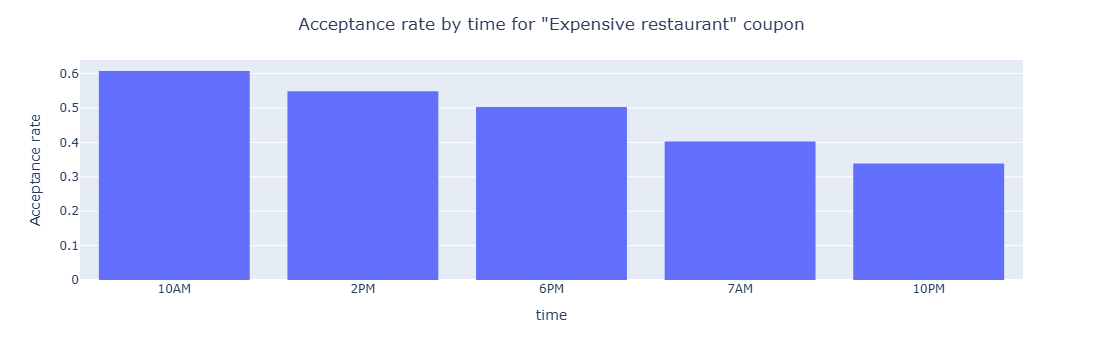

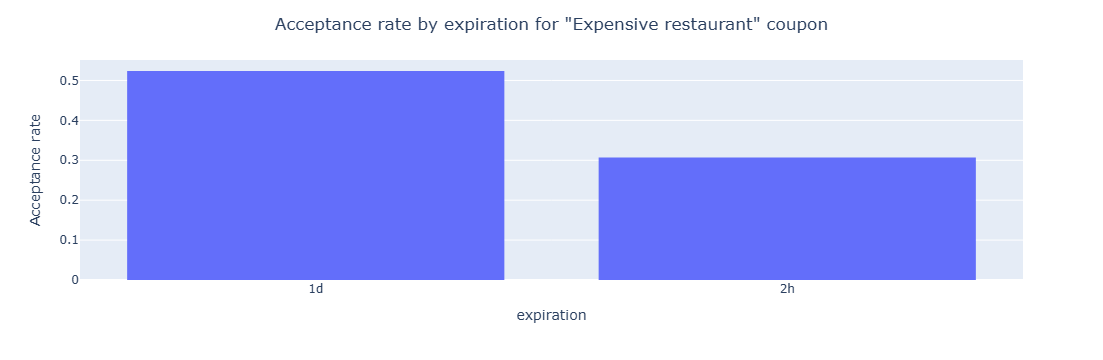

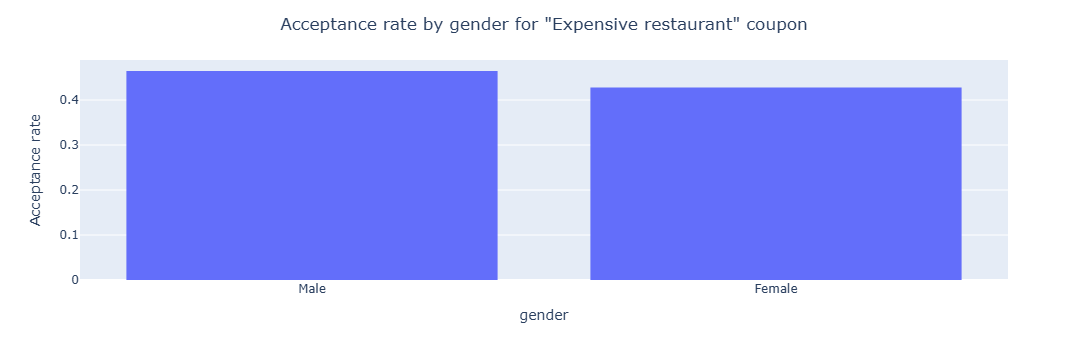

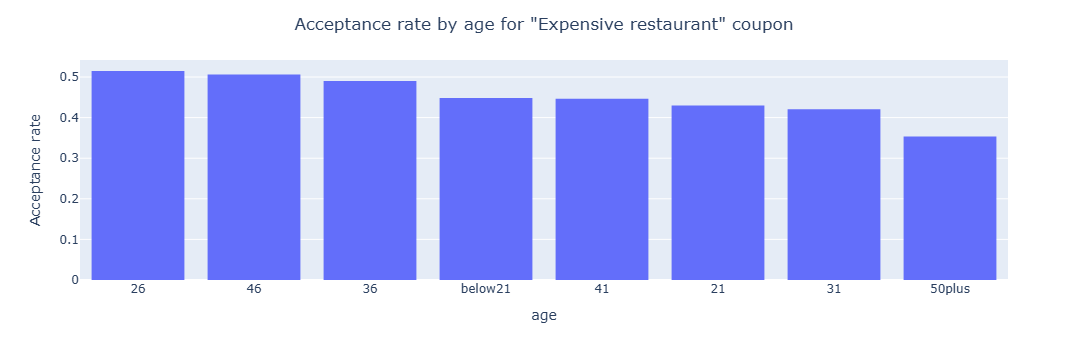

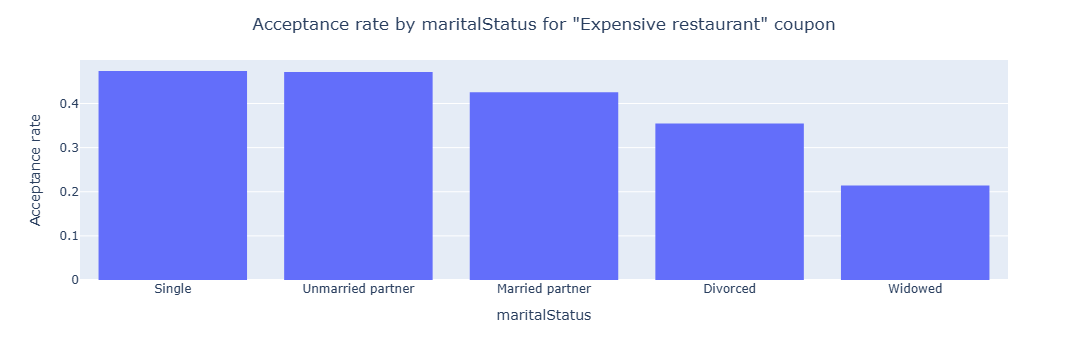

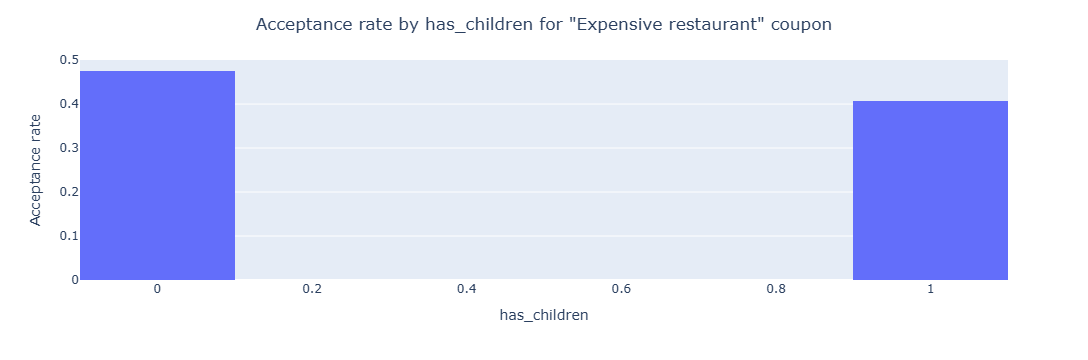

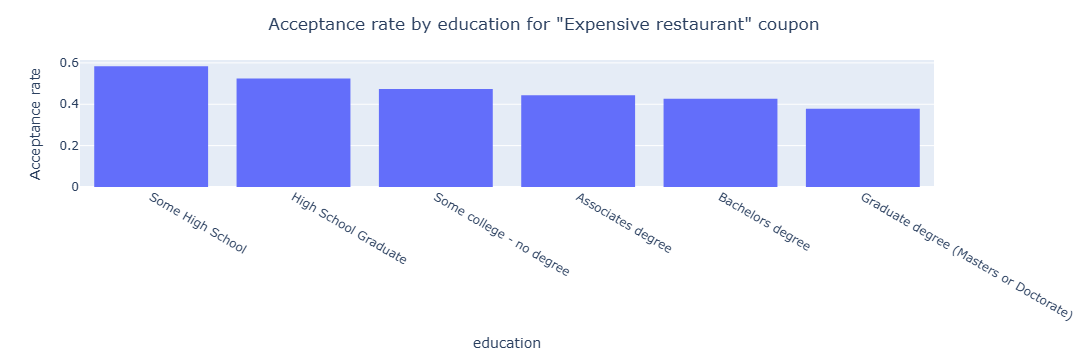

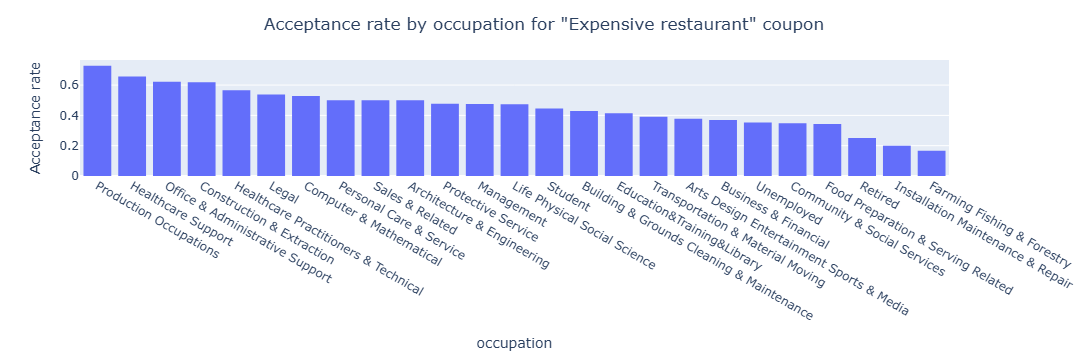

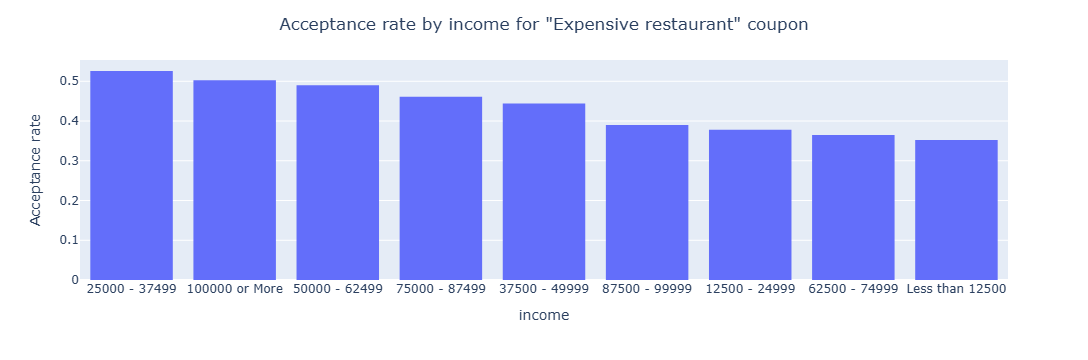

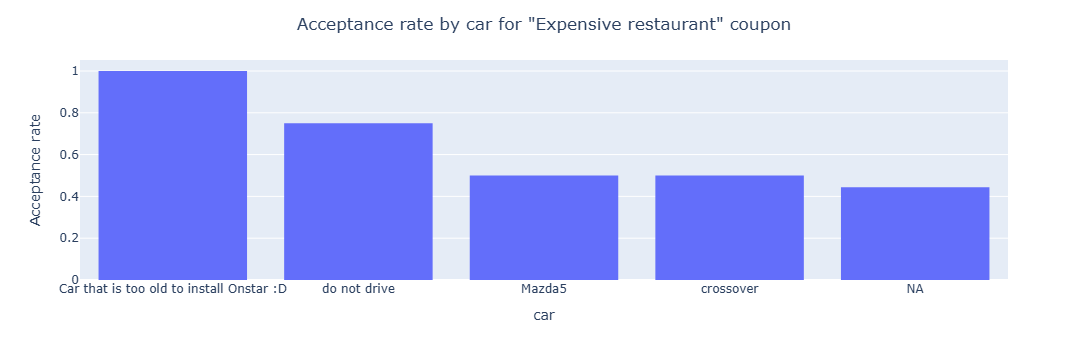

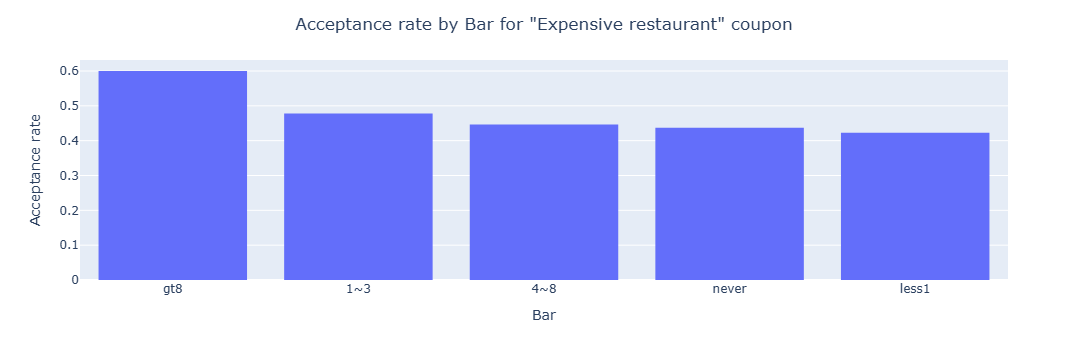

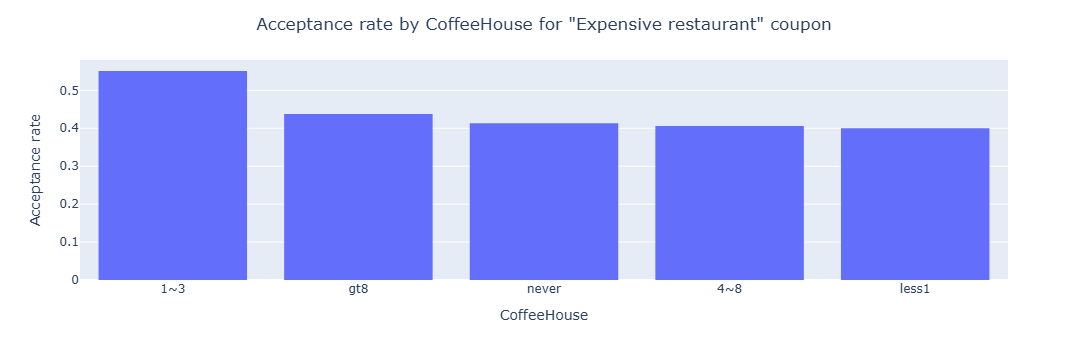

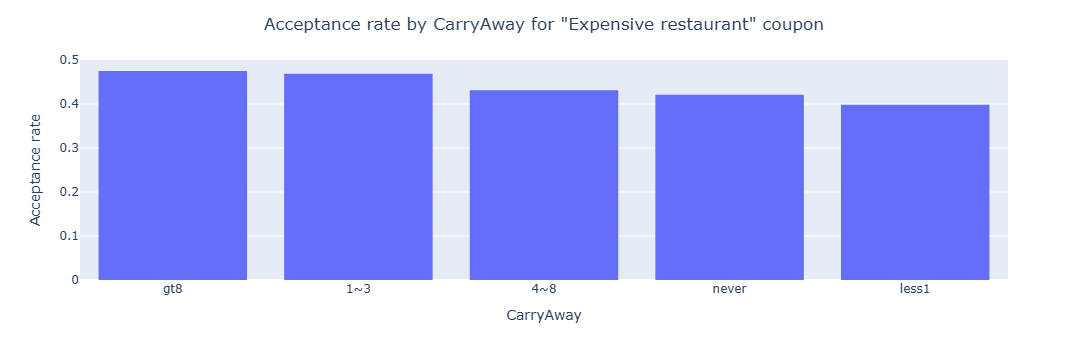

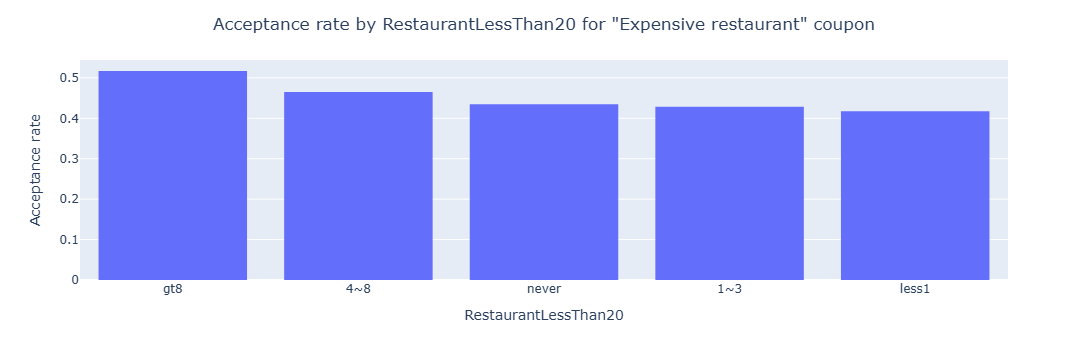

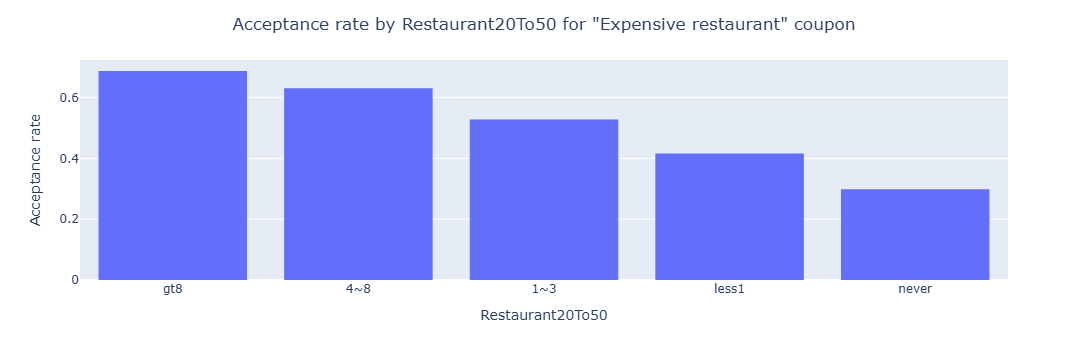

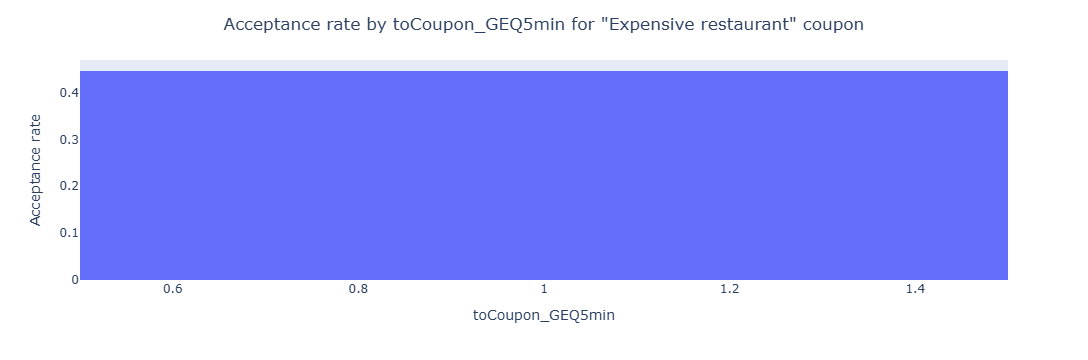

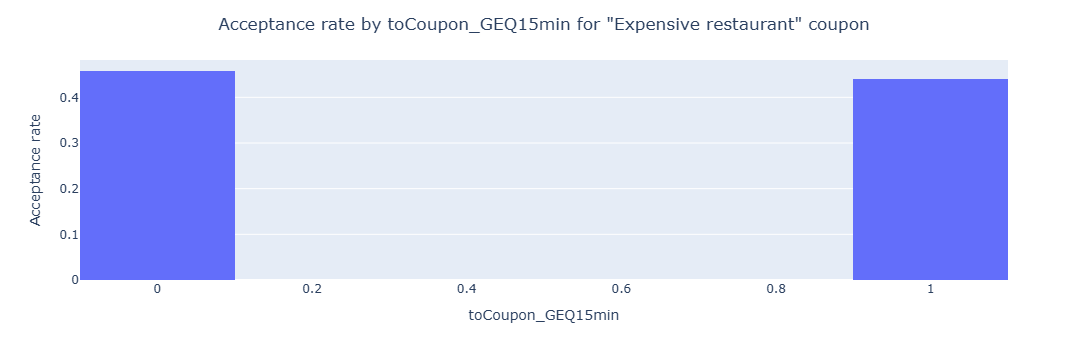

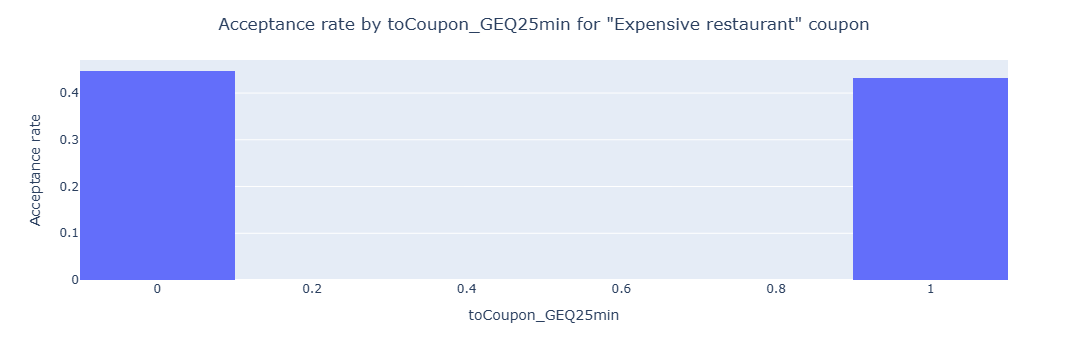

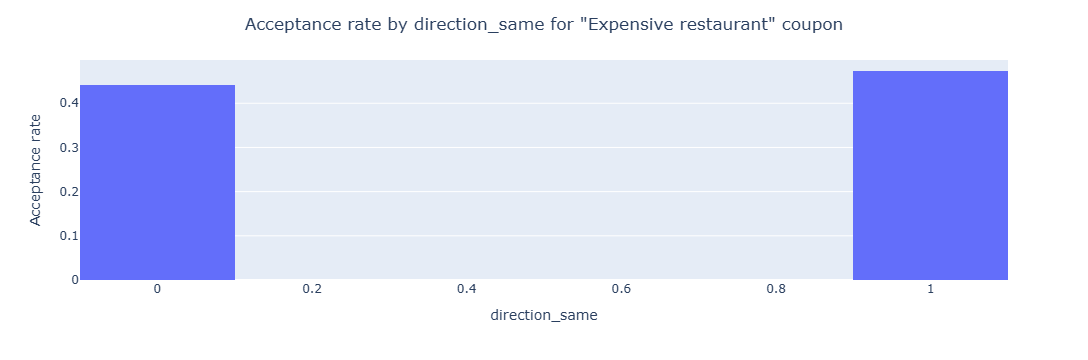

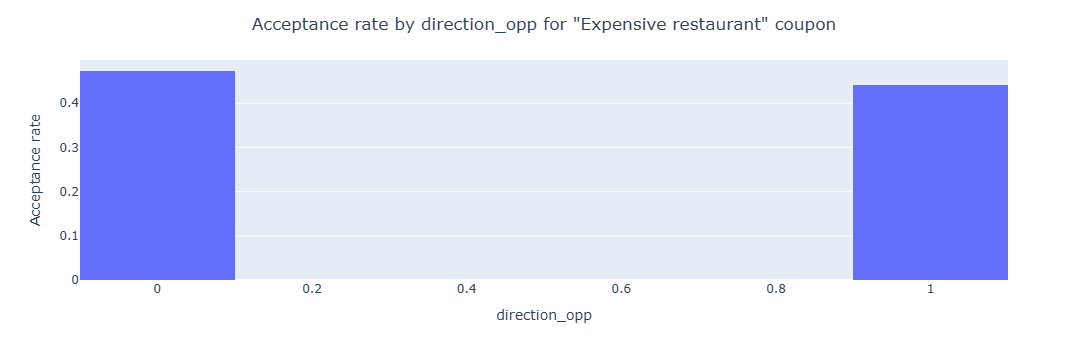

In [103]:
# 1) We create a new DataFrame that contains just the "Restaurant(20-50)" coupons.

data_restaurant_expensive = data.query('coupon == "Restaurant(20-50)"')
data_restaurant_expensive.head()

# 2) What proportion of "Restaurant(20-50)" coupons were accepted?

data_restaurant_expensive['Y'].value_counts(normalize = True)
#The proportion of "Restaurant(20-50)" coupons which were accepted is about 45%

# 3) Compare the acceptance rate between those who go to a expensive restaurant 3 or fewer times a month to those who go more.
data_restaurant_expensive.groupby(data_restaurant_expensive['Restaurant20To50'].isin(['1~3','less1', 'never']))['Y'].value_counts(normalize = True)
# we see that the acceptance rate of those who go to an expensive restaurant 3 or fewer times a month is about 43%
# and the acceptance rate of those who go more is about 65%
# so the acceptance rate of those who go to an expensive restaurant 3 or fewer times a month is a lot less than those who go more

# 4) Compare the acceptance rate of those who go to an expensive restaurant depending on each categorical column
categorical_columns = data_restaurant_expensive.select_dtypes(include=['object', 'category', 'int64']).columns
# we create an histogram of the acceptance rate by each of the categorical column
for col in categorical_columns:
    if col not in ['coupon', 'Y']:  
        data_restaurant_expensive_col = data_restaurant_expensive.groupby([col])['Y'].value_counts(normalize = True).to_frame(name='acceptance rate').reset_index().sort_values(by = 'acceptance rate', ascending = False).query('Y == 1')
        plt_col = px.histogram(data_restaurant_expensive_col, x = col, y = 'acceptance rate', nbins = 10)
        plt_col.update_layout(title=f'Acceptance rate by {col} for "Expensive restaurant" coupon', yaxis_title="Acceptance rate", title_x = 0.5)
        plt_col.show()
        plt_col.write_html(f'data\\Acceptance rate by {col} for Expensive restaurant coupon.html')
# we noticed that the acceptance rate of the "Restaurant(20-50)" coupons is higher : 
# - for drivers who go to no urgent place
# - for drivers who travel with partner
# - during Sunny weather
# - when the temperature is not too cold
# - between 10 AM and 6 PM
# - when the coupon expires before 1 day
# - for drivers who are less than 50 years old
# - for single or unmarried partners
# - for drivers with lower level of education
# - for drivers in the occupation of : Production occupations
# - for drivers with higher income
# - for drivers who go more than 8 times a month to Bars or cheap restaurants or expensive restaurants
# - for drivers who order more than 8 times a month Take away food      